# 1. **Motivation**

## What is your dataset?

The dataset consists of traffic collisions in New York from the period 2013–2025. It contains 
more than 2 million rows with features including crash date and time, borough, GPS coordinates, 
street names, number of persons injured and killed (broken down by pedestrians, cyclists, and 
motorists), contributing factors per vehicle involved, and vehicle types. We supplement this 
with hourly weather data (precipitation, wind speed, cloud cover, temperature) fetched from 
Open-Meteo for the same period

## Why did you choose this/these particular dataset(s)?

With more than 2 millino rows and x features the dataset is quite large and rich for  a multi-diemnsional analysis. It has geospatial enabling geographic plots, a temporal dimensions with both dates and time spanning over a decade enabling trend analysis. Also the data contains information on lost lives providing a motivation an guidance for the data analysis. 

## What was your goal for the end user's experience?

The goal was to present a clear accessible analysis to the user higlighting essential findings in the dataset and ways to assess it. Ideally the user should feel carried through the analysis and story without it feeling too technical. The user should have a clear sense of what was done and explored motivating them to either use some of the same ideas or take an entirely different approach based on our results.  

# 2. **Basic Stats**: Let's understand the dataset better

## Write about your choices in data cleaning and preprocessing

## Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis

# 3. **Data Analysis**

## Describe your data analysis and explain what you've learned about the dataset

In [25]:
# imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
crash_df   = pd.read_parquet("datasets/crashes_clean.parquet")   # one row per crash, indexed by c_COLLISION_ID
vehicle_df = pd.read_parquet("datasets/vehicles_clean.parquet")  # one row per vehicle, indexed by v_COLLISION_ID (non-unique)
person_df  = pd.read_parquet("datasets/persons_clean.parquet")   # one row per person, indexed by p_COLLISION_ID (non-unique)

print(f"crashes:  {len(crash_df):,}")
print(f"vehicles: {len(vehicle_df):,}")
print(f"persons:  {len(person_df):,}")

# --- merge helpers ---
# All return c_COLLISION_ID as a plain column (reset_index) so downstream code
# can reference it directly. The COLLISION_ID index is preserved in the source dfs.
# crashes_with_persons joins only on COLLISION_ID, so pedestrians are included.

def crashes_with_vehicles(crash_cols=None, vehicle_cols=None):
    """One row per (crash, vehicle). c_COLLISION_ID returned as a regular column."""
    c = crash_df[crash_cols] if crash_cols else crash_df
    v = vehicle_df[vehicle_cols] if vehicle_cols else vehicle_df
    return c.merge(v, left_index=True, right_index=True, how="left").reset_index()

def crashes_with_persons(crash_cols=None, person_cols=None):
    """One row per (crash, person). Includes pedestrians and cyclists.
    c_COLLISION_ID returned as a regular column."""
    c = crash_df[crash_cols] if crash_cols else crash_df
    p = person_df[person_cols] if person_cols else person_df
    return c.merge(p, left_index=True, right_index=True, how="left").reset_index()

def vehicles_with_persons(vehicle_cols=None, person_cols=None):
    """One row per (vehicle, person). Links persons to the specific vehicle they were in.
    Pedestrians are excluded (they have no vehicle link).
    Join key columns v_COLLISION_ID, v_UNIQUE_ID, p_VEHICLE_ID always included."""
    v = vehicle_df.reset_index()
    p = person_df.reset_index()
    if vehicle_cols is not None:
        keep = list(dict.fromkeys(["v_COLLISION_ID", "v_UNIQUE_ID"] + list(vehicle_cols)))
        v = v[keep]
    if person_cols is not None:
        keep = list(dict.fromkeys(["p_COLLISION_ID", "p_VEHICLE_ID"] + list(person_cols)))
        p = p[keep]
    return v.merge(p, left_on=["v_COLLISION_ID", "v_UNIQUE_ID"],
                      right_on=["p_COLLISION_ID", "p_VEHICLE_ID"], how="left")

crashes:  1,527,549
vehicles: 3,042,734
persons:  3,597,629


## 0. Datasets Overview

Before we go into more focused research and data analysis, we want to understand the data we are working with a bit and have an initial overview of the patterns and stored information. So as a first step, we analyze the crash dataset, then vehicle dataset and finally the person dataset. 

### Crash Dataset

In [27]:
date_min = pd.to_datetime(crash_df['c_CRASH DATE']).min()
date_max = pd.to_datetime(crash_df['c_CRASH DATE']).max()

n_total   = len(crash_df)
n_serious = ((crash_df['c_NUMBER OF PERSONS INJURED'] > 0) |
             (crash_df['c_NUMBER OF PERSONS KILLED'] > 0)).sum()
n_killed  = (crash_df['c_NUMBER OF PERSONS KILLED'] > 0).sum()

print(f"Date range      : {date_min.date()}  →  {date_max.date()}")
print(f"Total crashes   : {n_total:,}")
print(f"  ≥1 injured or killed : {n_serious:,}  ({n_serious / n_total * 100:.1f}%)")
print(f"  ≥1 killed            : {n_killed:,}   ({n_killed  / n_total * 100:.2f}%)")

Date range      : 2012-07-01  →  2026-04-03
Total crashes   : 1,527,549
  ≥1 injured or killed : 368,546  (24.1%)
  ≥1 killed            : 2,012   (0.13%)


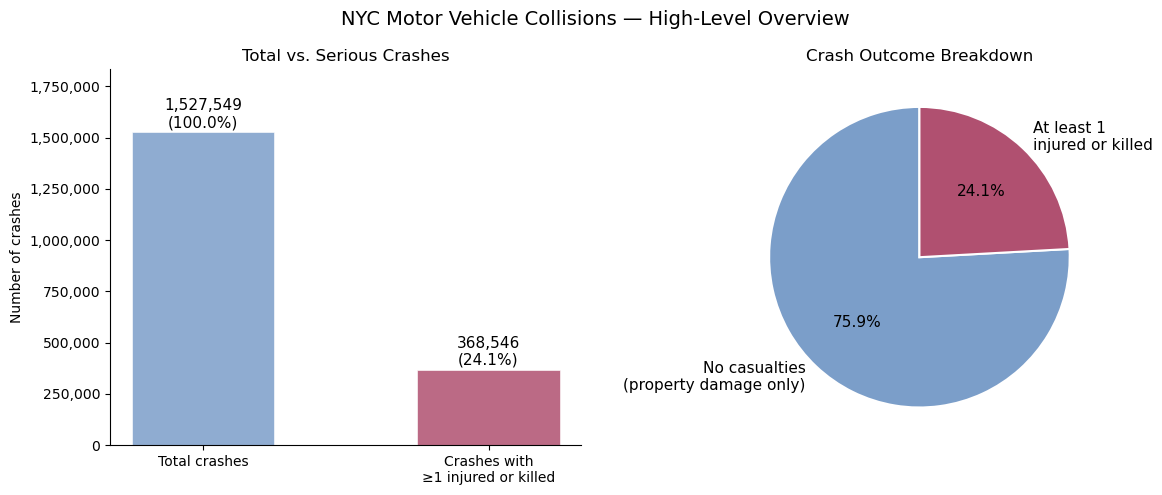

In [28]:
total   = len(crash_df)
serious = ((crash_df['c_NUMBER OF PERSONS INJURED'] > 0) |
           (crash_df['c_NUMBER OF PERSONS KILLED'] > 0)).sum()
no_cas  = total - serious

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('NYC Motor Vehicle Collisions — High-Level Overview', fontsize=14)

# bar: total vs with casualties
categories = ['Total crashes', 'Crashes with\n≥1 injured or killed']
values     = [total, serious]
bar_colors = ['#7B9EC9', '#B05070']

bars = axes[0].bar(categories, values, color=bar_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.005,
                 f'{val:,}\n({val / total * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[0].set_title('Total vs. Serious Crashes', fontsize=12)
axes[0].set_ylabel('Number of crashes')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, total * 1.20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# pie: outcome breakdown
axes[1].pie(
    [no_cas, serious],
    labels=['No casualties\n(property damage only)', 'At least 1\ninjured or killed'],
    colors=['#7B9EC9', '#B05070'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11)
)
axes[1].set_title('Crash Outcome Breakdown', fontsize=12)

plt.tight_layout()
plt.show()

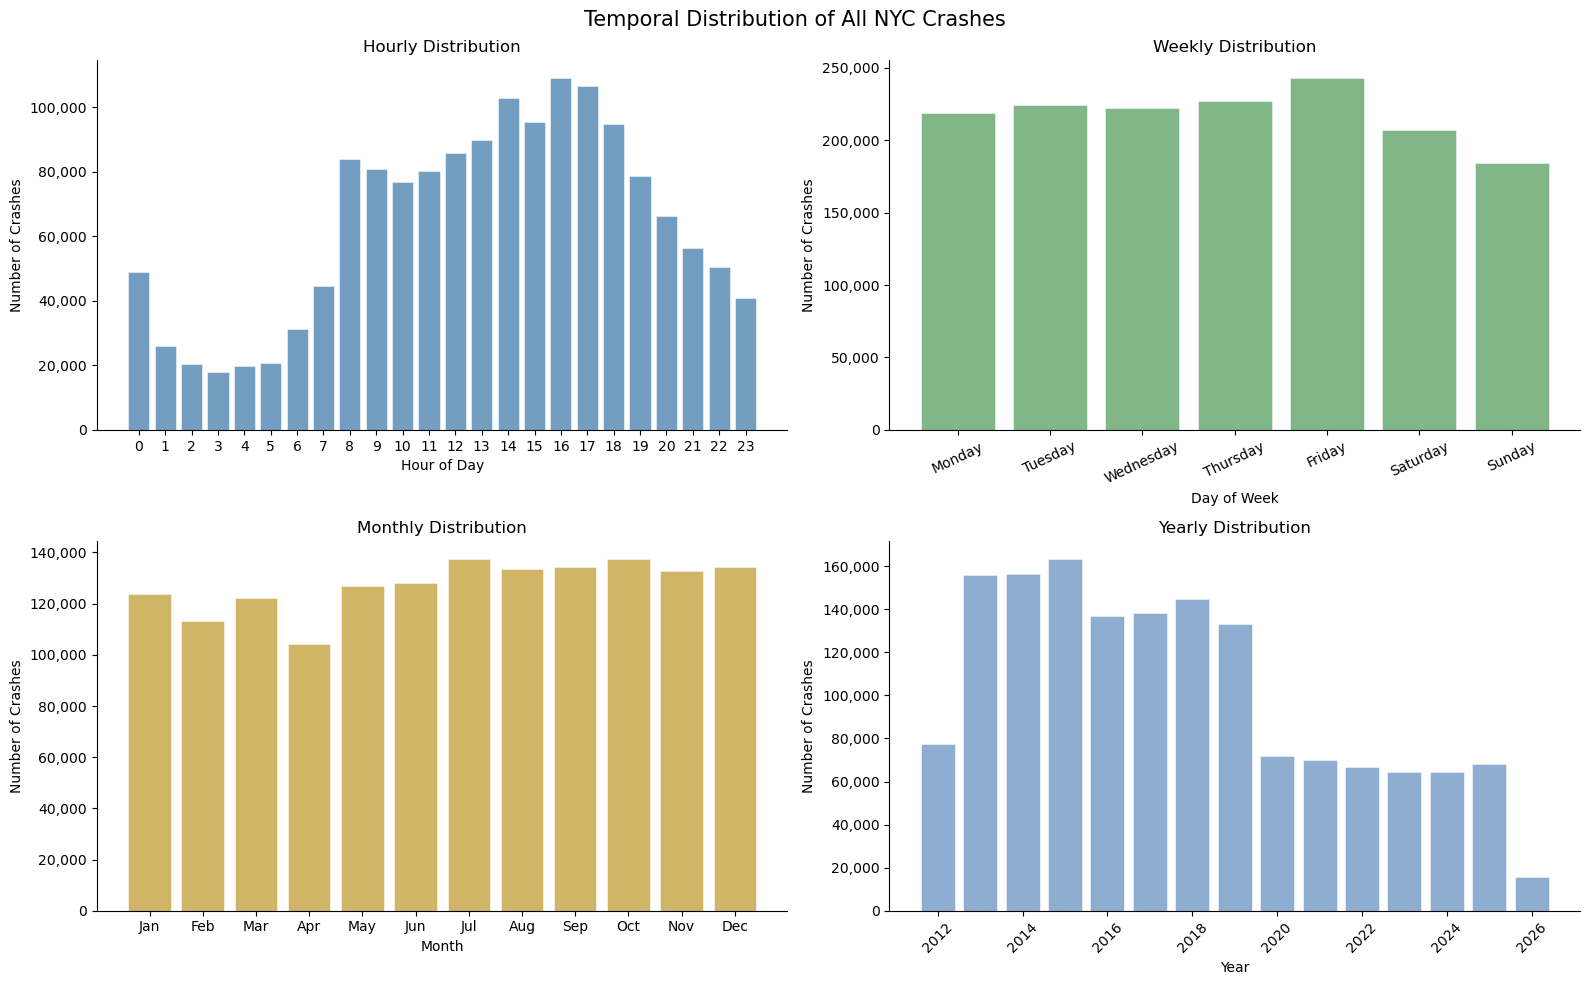

In [29]:
_date  = pd.to_datetime(crash_df['c_CRASH DATE'])
_hour  = pd.to_datetime(crash_df['c_CRASH TIME'].astype(str), format='mixed', errors='coerce').dt.hour

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_labels  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

hour_counts    = _hour.value_counts().sort_index()
weekday_counts = _date.dt.day_name().value_counts().reindex(weekday_order)
month_counts   = _date.dt.month.value_counts().sort_index().reindex(range(1, 13))
year_counts    = _date.dt.year.value_counts().sort_index()

bar_kw = dict(alpha=0.85, edgecolor='white', linewidth=0.4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Distribution of All NYC Crashes', fontsize=15)

axes[0, 0].bar(hour_counts.index, hour_counts.values, color='#5B8DB8', **bar_kw)
axes[0, 0].set_title('Hourly Distribution')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[0, 1].bar(weekday_order, weekday_counts.values, color='#6BAA75', **bar_kw)
axes[0, 1].set_title('Weekly Distribution')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Number of Crashes')
axes[0, 1].tick_params(axis='x', rotation=25)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1, 0].bar(range(1, 13), month_counts.values, color='#C9A84C', **bar_kw)
axes[1, 0].set_title('Monthly Distribution')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Crashes')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_labels)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1, 1].bar(year_counts.index, year_counts.values, color='#7B9EC9', **bar_kw)
axes[1, 1].set_title('Yearly Distribution')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Crashes')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Pre-Pandemic vs. Post-Pandemic Temporal Analysis

We split the dataset at 2020: **pre-pandemic (2013–2019)** captures the baseline traffic era; **post-pandemic (2020 onwards)** reflects the dramatic shifts in commuting patterns, remote work adoption, and road use that followed COVID-19.

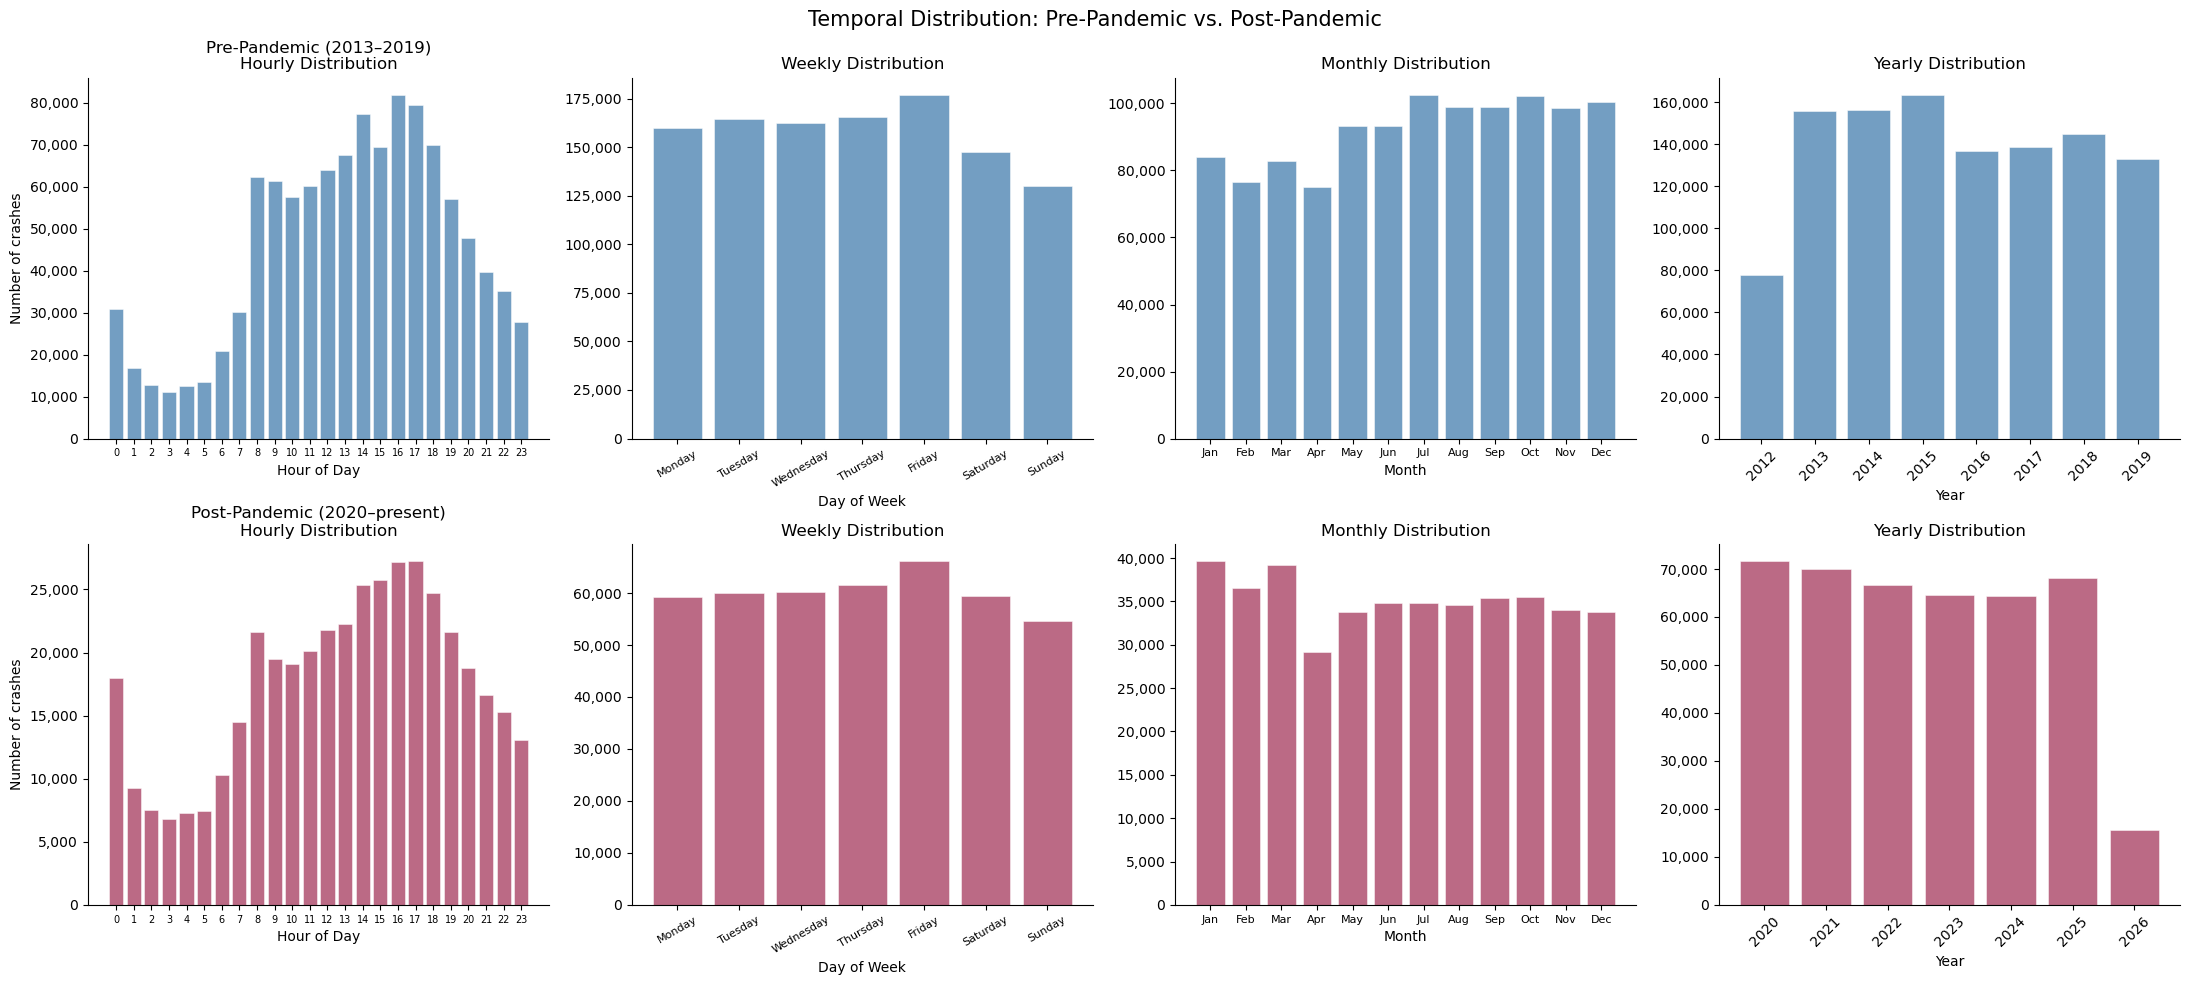

In [30]:
_year = _date.dt.year
pre_mask  = _year < 2020
post_mask = _year >= 2020

periods = [
    ('Pre-Pandemic (2013–2019)',     pre_mask,  '#5B8DB8'),
    ('Post-Pandemic (2020–present)', post_mask, '#B05070'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Temporal Distribution: Pre-Pandemic vs. Post-Pandemic', fontsize=15)

for row, (label, mask, color) in enumerate(periods):
    h = _hour[mask].value_counts().sort_index()
    w = _date[mask].dt.day_name().value_counts().reindex(weekday_order)
    m = _date[mask].dt.month.value_counts().sort_index().reindex(range(1, 13))
    y = _date[mask].dt.year.value_counts().sort_index()

    axes[row, 0].bar(h.index, h.values, color=color, **bar_kw)
    axes[row, 0].set_title(f'{label}\nHourly Distribution')
    axes[row, 0].set_xlabel('Hour of Day')
    axes[row, 0].set_ylabel('Number of crashes')
    axes[row, 0].set_xticks(range(0, 24))
    axes[row, 0].tick_params(axis='x', labelsize=7)
    axes[row, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    axes[row, 1].bar(weekday_order, w.values, color=color, **bar_kw)
    axes[row, 1].set_title('Weekly Distribution')
    axes[row, 1].set_xlabel('Day of Week')
    axes[row, 1].tick_params(axis='x', rotation=30, labelsize=8)
    axes[row, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    axes[row, 2].bar(range(1, 13), m.values, color=color, **bar_kw)
    axes[row, 2].set_title('Monthly Distribution')
    axes[row, 2].set_xlabel('Month')
    axes[row, 2].set_xticks(range(1, 13))
    axes[row, 2].set_xticklabels(month_labels, fontsize=8)
    axes[row, 2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    axes[row, 3].bar(y.index, y.values, color=color, **bar_kw)
    axes[row, 3].set_title('Yearly Distribution')
    axes[row, 3].set_xlabel('Year')
    axes[row, 3].tick_params(axis='x', rotation=45)
    axes[row, 3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

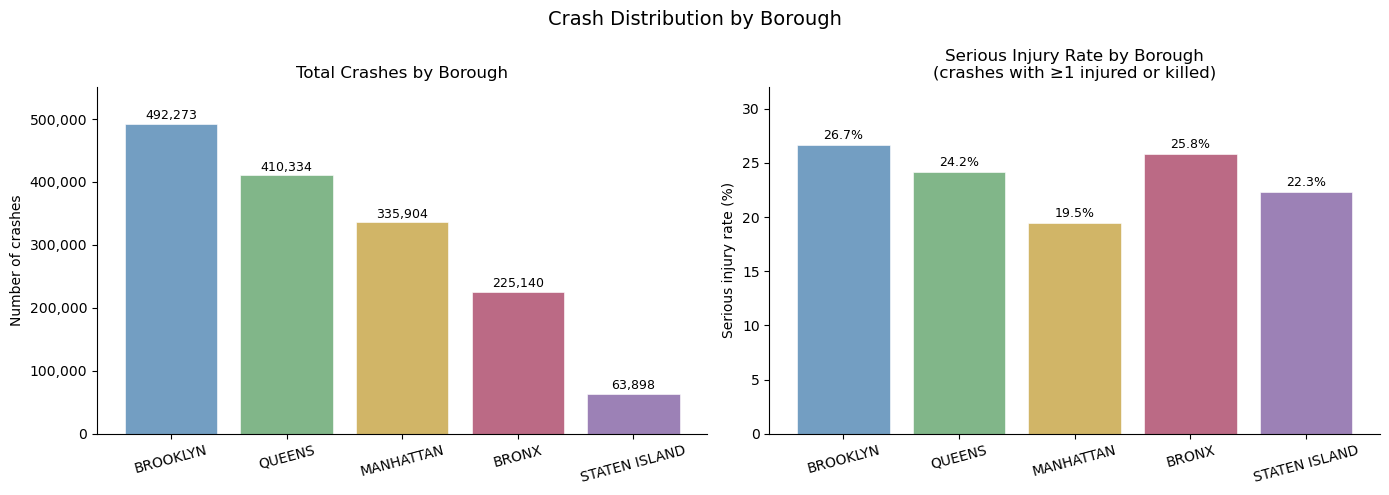

In [31]:
if 'c_BOROUGH' in crash_df.columns:
    bor = crash_df[['c_BOROUGH', 'c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED']].dropna(subset=['c_BOROUGH'])
    bor = bor.copy()
    bor['is_serious'] = (bor['c_NUMBER OF PERSONS INJURED'] > 0) | (bor['c_NUMBER OF PERSONS KILLED'] > 0)

    borough_order = bor['c_BOROUGH'].value_counts().index.tolist()
    total_b   = bor.groupby('c_BOROUGH').size().reindex(borough_order)
    serious_b = bor[bor['is_serious']].groupby('c_BOROUGH').size().reindex(borough_order)
    rate_b    = (serious_b / total_b * 100).round(1)

    palette = ['#5B8DB8', '#6BAA75', '#C9A84C', '#B05070', '#8B6BAA']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Crash Distribution by Borough', fontsize=14)

    bars = axes[0].bar(borough_order, total_b.values,
                       color=palette[:len(borough_order)], alpha=0.85,
                       edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, total_b.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + total_b.max() * 0.005,
                     f'{val:,}', ha='center', va='bottom', fontsize=9)
    axes[0].set_title('Total Crashes by Borough', fontsize=12)
    axes[0].set_ylabel('Number of crashes')
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].set_ylim(0, total_b.max() * 1.12)

    bars = axes[1].bar(borough_order, rate_b.values,
                       color=palette[:len(borough_order)], alpha=0.85,
                       edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, rate_b.values):
        if pd.notna(val):
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + rate_b.max() * 0.01,
                         f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].set_title('Serious Injury Rate by Borough\n(crashes with ≥1 injured or killed)', fontsize=12)
    axes[1].set_ylabel('Serious injury rate (%)')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].set_ylim(0, rate_b.max() * 1.2)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

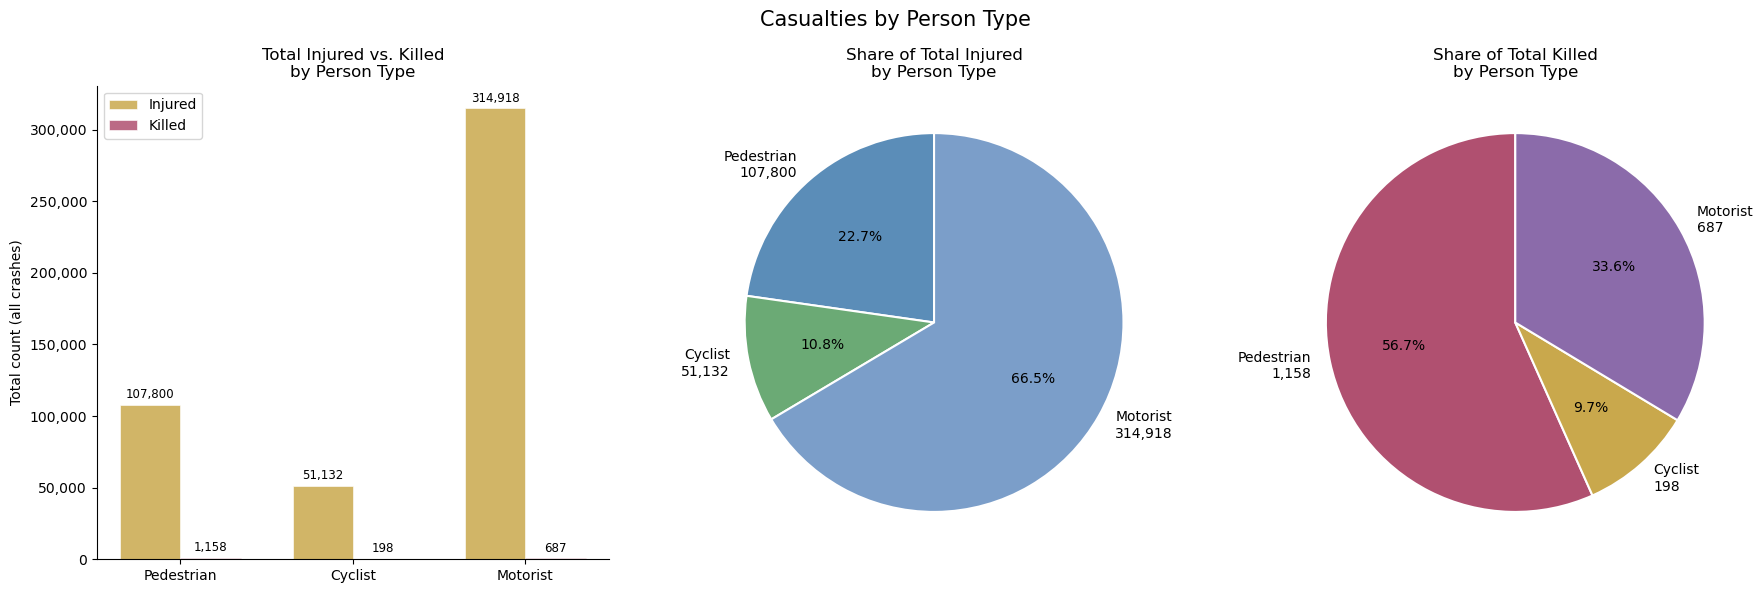

Fatality rate by person type (killed / (injured + killed)):
  Pedestrian    injured: 107,800   killed: 1,158   fatality rate: 1.06%
  Cyclist       injured: 51,132   killed:   198   fatality rate: 0.39%
  Motorist      injured: 314,918   killed:   687   fatality rate: 0.22%


In [54]:
person_types = ['Pedestrian', 'Cyclist', 'Motorist']
inj_cols = ['c_NUMBER OF PEDESTRIANS INJURED', 'c_NUMBER OF CYCLIST INJURED',  'c_NUMBER OF MOTORIST INJURED']
kil_cols = ['c_NUMBER OF PEDESTRIANS KILLED',  'c_NUMBER OF CYCLIST KILLED',   'c_NUMBER OF MOTORIST KILLED']

injured_totals = crash_df[inj_cols].sum().values
killed_totals  = crash_df[kil_cols].sum().values

x    = np.arange(len(person_types))
w    = 0.35
fmt  = plt.FuncFormatter(lambda v, _: f'{int(v):,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Casualties by Person Type', fontsize=15)

# --- grouped bar: injured vs killed side by side ---
ax = axes[0]
bars_i = ax.bar(x - w / 2, injured_totals, w, label='Injured',
                color='#C9A84C', alpha=0.85, edgecolor='white', linewidth=0.5)
bars_k = ax.bar(x + w / 2, killed_totals,  w, label='Killed',
                color='#B05070', alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(list(bars_i) + list(bars_k), list(injured_totals) + list(killed_totals)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(injured_totals) * 0.008,
            f'{int(val):,}', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Total Injured vs. Killed\nby Person Type', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(person_types)
ax.set_ylabel('Total count (all crashes)')
ax.yaxis.set_major_formatter(fmt)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- pie: share of injured ---
colors_pie = ['#5B8DB8', '#6BAA75', '#7B9EC9']
axes[1].pie(injured_totals,
            labels=[f'{t}\n{v:,}' for t, v in zip(person_types, injured_totals)],
            colors=colors_pie, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops=dict(fontsize=10))
axes[1].set_title('Share of Total Injured\nby Person Type', fontsize=12)

# --- pie: share of killed ---
colors_kill = ['#B05070', '#C9A84C', '#8B6BAA']
axes[2].pie(killed_totals,
            labels=[f'{t}\n{v:,}' for t, v in zip(person_types, killed_totals)],
            colors=colors_kill, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops=dict(fontsize=10))
axes[2].set_title('Share of Total Killed\nby Person Type', fontsize=12)

plt.tight_layout()
plt.show()

# fatality rate per type
print("Fatality rate by person type (killed / (injured + killed)):")
for t, inj, kil in zip(person_types, injured_totals, killed_totals):
    total_cas = inj + kil
    rate = kil / total_cas * 100 if total_cas > 0 else 0
    print(f"  {t:12s}  injured: {int(inj):>6,}   killed: {int(kil):>5,}   fatality rate: {rate:.2f}%")

In [55]:
inj_sum = (crash_df['c_NUMBER OF PEDESTRIANS INJURED'] +
           crash_df['c_NUMBER OF CYCLIST INJURED'] +
           crash_df['c_NUMBER OF MOTORIST INJURED'])

diff = crash_df['c_NUMBER OF PERSONS INJURED'] - inj_sum
print(f"Rows where they match   : {(diff == 0).sum():,}")
print(f"Rows where total > sum  : {(diff > 0).sum():,}")  # unattributed persons
print(f"Rows where total < sum  : {(diff < 0).sum():,}")  # sub-col overcounting
print(f"Total unattributed inj  : {diff.clip(lower=0).sum():.0f}")


Rows where they match   : 1,519,618
Rows where total > sum  : 7,853
Rows where total < sum  : 78
Total unattributed inj  : 8292


### Vehicle Dataset

A quick factual baseline for the vehicle-level data: who is behind the wheel, how many people are in the car, which direction they travel, and the condition of their licence.

In [56]:
total_v = len(vehicle_df)
print(f'Total vehicle records: {total_v:,}\n')

# driver sex
print('=== Driver Sex ===')
for val, cnt in vehicle_df['v_DRIVER_SEX'].value_counts().items():
    print(f'  {str(val):20s}: {cnt:>8,}  ({cnt/total_v*100:.1f}%)')

# vehicle occupants
print('\n=== Vehicle Occupants (reported) ===')
occ = vehicle_df['v_VEHICLE_OCCUPANTS'].value_counts().sort_index()
for val, cnt in occ.items():
    label = f'{int(val)}' if val == int(val) else str(val)
    print(f'  {label:>4} occupant(s): {cnt:>8,}  ({cnt/total_v*100:.1f}%)')

# travel direction
print('\n=== Travel Direction ===')
for val, cnt in vehicle_df['v_TRAVEL_DIRECTION'].value_counts().items():
    print(f'  {str(val):30s}: {cnt:>8,}  ({cnt/total_v*100:.1f}%)')

# driver licence status
print('\n=== Driver Licence Status ===')
for val, cnt in vehicle_df['v_DRIVER_LICENSE_STATUS'].value_counts().items():
    print(f'  {str(val):30s}: {cnt:>8,}  ({cnt/total_v*100:.1f}%)')

Total vehicle records: 3,042,734

=== Driver Sex ===
  M                   :  957,243  (31.5%)
  F                   :  328,472  (10.8%)
  U                   :    5,430  (0.2%)

=== Vehicle Occupants (reported) ===
     0 occupant(s):  364,338  (12.0%)
     1 occupant(s): 1,014,749  (33.3%)
     2 occupant(s):  202,035  (6.6%)
     3 occupant(s):   56,278  (1.8%)
     4 occupant(s):   22,150  (0.7%)
     5 occupant(s):    7,929  (0.3%)
     6 occupant(s):    2,765  (0.1%)
     7 occupant(s):    1,247  (0.0%)
     8 occupant(s):      811  (0.0%)
     9 occupant(s):      632  (0.0%)
    10 occupant(s):      511  (0.0%)
    11 occupant(s):      376  (0.0%)
    12 occupant(s):      271  (0.0%)
    13 occupant(s):      206  (0.0%)
    14 occupant(s):      183  (0.0%)
    15 occupant(s):      164  (0.0%)
    16 occupant(s):      114  (0.0%)
    17 occupant(s):       87  (0.0%)
    18 occupant(s):       58  (0.0%)
    19 occupant(s):       48  (0.0%)
    20 occupant(s):       70  (0.0%)
    

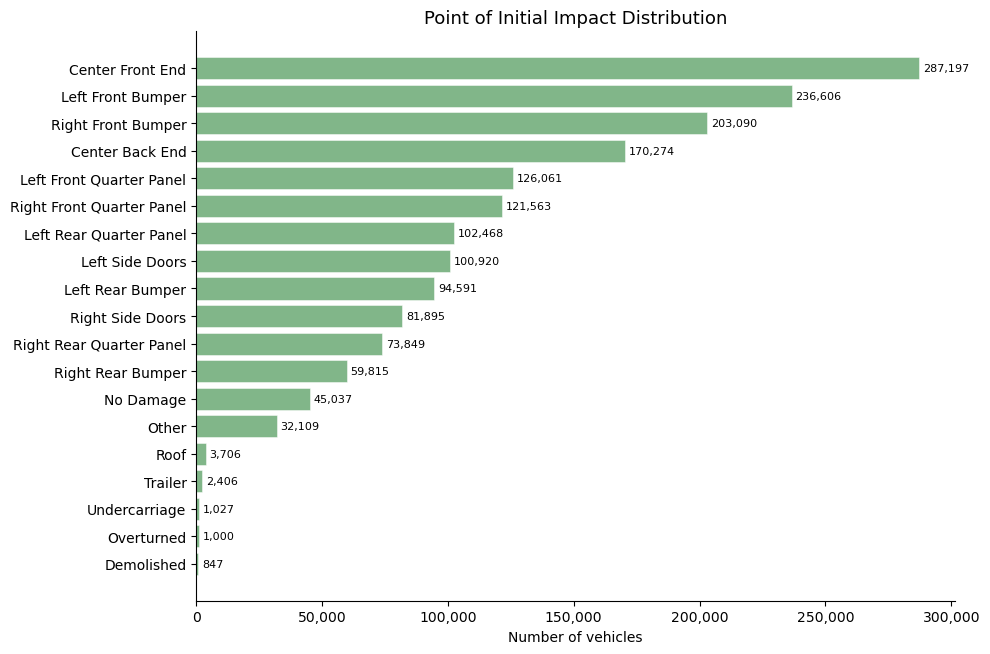

In [57]:
impact = (vehicle_df['v_POINT_OF_IMPACT']
          .dropna()
          .replace('', float('nan'))
          .dropna())
impact_counts = impact.value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(impact_counts) * 0.35)))
ax.barh(impact_counts.index, impact_counts.values,
        color='#6BAA75', alpha=0.85, edgecolor='white', linewidth=0.4)
for i, val in enumerate(impact_counts.values):
    ax.text(val + impact_counts.max() * 0.005, i,
            f'{val:,}', va='center', fontsize=8)
ax.set_title('Point of Initial Impact Distribution', fontsize=13)
ax.set_xlabel('Number of vehicles')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

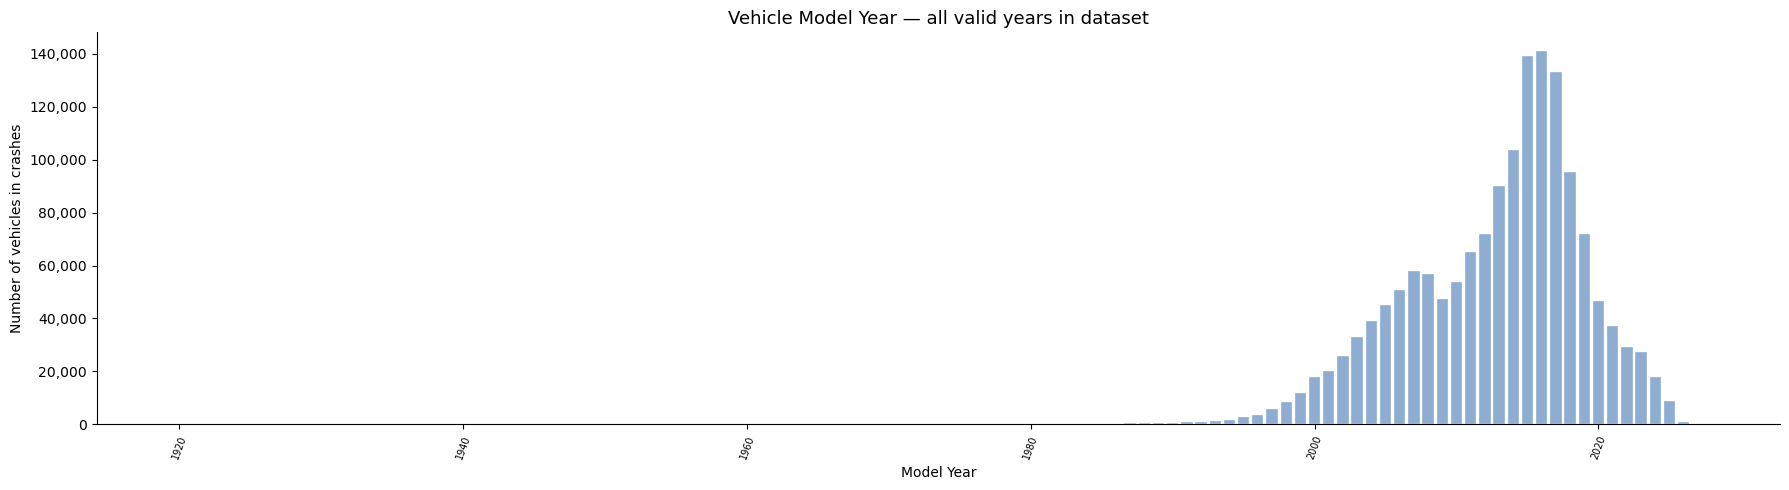

In [58]:
yr = vehicle_df['v_VEHICLE_YEAR'].dropna()
yr = yr[(yr > 1900) & (yr <= pd.Timestamp.now().year + 1)].astype(int)
yr_counts = yr.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(yr_counts.index, yr_counts.values, color='#7B9EC9', alpha=0.85,
       edgecolor='white', linewidth=0.3)
ax.set_title('Vehicle Model Year — all valid years in dataset', fontsize=13)
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of vehicles in crashes')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=70, labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Person Dataset

A factual baseline for the person-level data: who is involved in crashes, what injuries they sustain, and what they were doing at the time.

In [59]:
total_p = len(person_df)
print(f'Total person records: {total_p:,}\n')

def print_dist(label, series, top=None):
    counts = series.value_counts(dropna=False)
    if top:
        counts = counts.head(top)
    print(f'=== {label} ===')
    for val, cnt in counts.items():
        display = str(val) if val is not None and str(val) != 'nan' else '(not reported)'
        print(f'  {display:50s}: {cnt:>8,}  ({cnt/total_p*100:.1f}%)')
    print()

print_dist('Person Type',          person_df['p_PERSON_TYPE'])
print_dist('Person Injury',         person_df['p_PERSON_INJURY'])
print_dist('Person Sex',            person_df['p_PERSON_SEX'])
print_dist('Pedestrian Action',     person_df['p_PED_ACTION'])
print_dist('Position in Vehicle',   person_df['p_POSITION_IN_VEHICLE'])
print_dist('Safety Equipment',      person_df['p_SAFETY_EQUIPMENT'])
print_dist('Bodily Injury',         person_df['p_BODILY_INJURY'], top=15)
print_dist('Emotional Status',      person_df['p_EMOTIONAL_STATUS'])

Total person records: 3,597,629

=== Person Type ===
  Occupant                                          : 3,411,869  (94.8%)
  Pedestrian                                        :  115,147  (3.2%)
  Bicyclist                                         :   60,952  (1.7%)
  Other Motorized                                   :    9,661  (0.3%)

=== Person Injury ===
  Unspecified                                       : 3,113,728  (86.5%)
  Injured                                           :  481,817  (13.4%)
  Killed                                            :    2,084  (0.1%)

=== Person Sex ===
  M                                                 : 1,926,339  (53.5%)
  F                                                 :  958,716  (26.6%)
  (not reported)                                    :  445,490  (12.4%)
  U                                                 :  267,084  (7.4%)

=== Pedestrian Action ===
  (not reported)                                    : 3,518,409  (97.8%)
  Crossing Wit

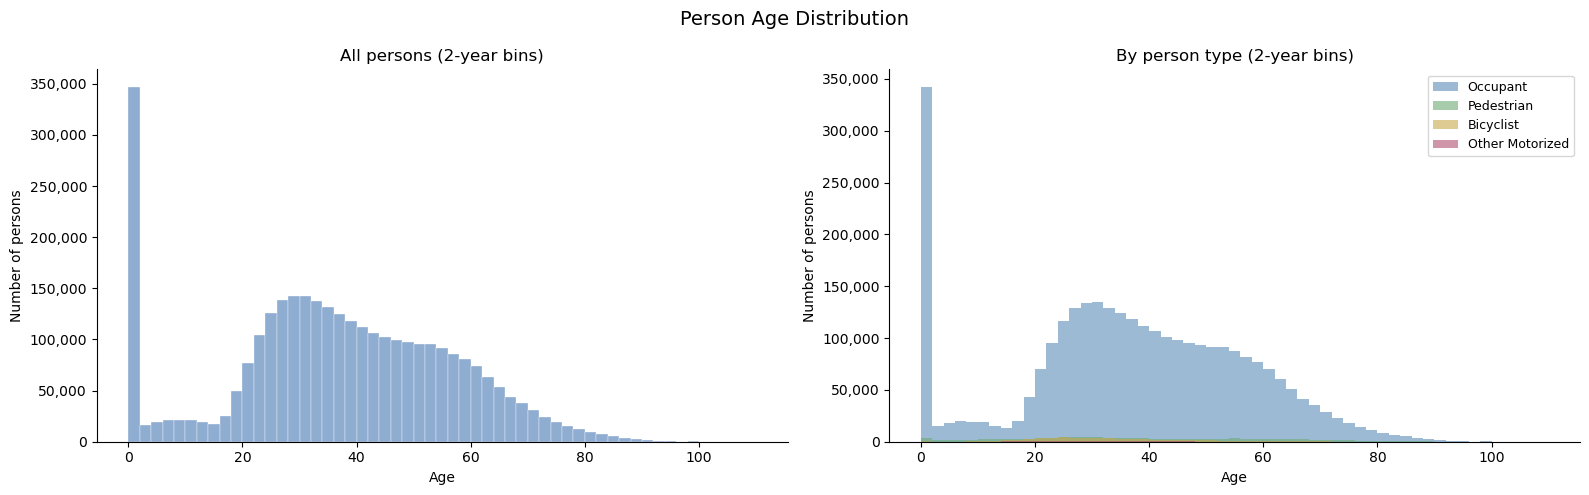

Age stats  —  min: 0  |  median: 36  |  mean: 36.2  |  max: 110


In [60]:
age = person_df['p_PERSON_AGE'].dropna()
age = age[(age >= 0) & (age <= 110)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Person Age Distribution', fontsize=14)

# left: full distribution as histogram
axes[0].hist(age, bins=range(0, 112, 2), color='#7B9EC9',
             alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_title('All persons (2-year bins)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of persons')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# right: by person type
type_order  = ['Occupant', 'Pedestrian', 'Bicyclist', 'Other Motorized']
type_colors = ['#5B8DB8', '#6BAA75', '#C9A84C', '#B05070']
for ptype, color in zip(type_order, type_colors):
    subset = person_df.loc[
        (person_df['p_PERSON_TYPE'] == ptype) &
        person_df['p_PERSON_AGE'].between(0, 110),
        'p_PERSON_AGE'
    ].dropna()
    if len(subset):
        axes[1].hist(subset, bins=range(0, 112, 2), alpha=0.6,
                     color=color, edgecolor='none', label=ptype)
axes[1].set_title('By person type (2-year bins)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of persons')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Age stats  —  min: {int(age.min())}  |  median: {int(age.median())}  '
      f'|  mean: {age.mean():.1f}  |  max: {int(age.max())}')

## Story-oriented data analysis

In this part of the data analysis, we focused on answering specific question that came to our minds when exploring the datasets. There are several main numbered questions that form a path that represents out train of thoughts in this process, and subquestions that go deeper into finding interesting patterns in the data. 

We start by asking a general question why do the collisions in NYC happen?

### Why do crashes happen?
#### Do the contributing factors differ between men and women?

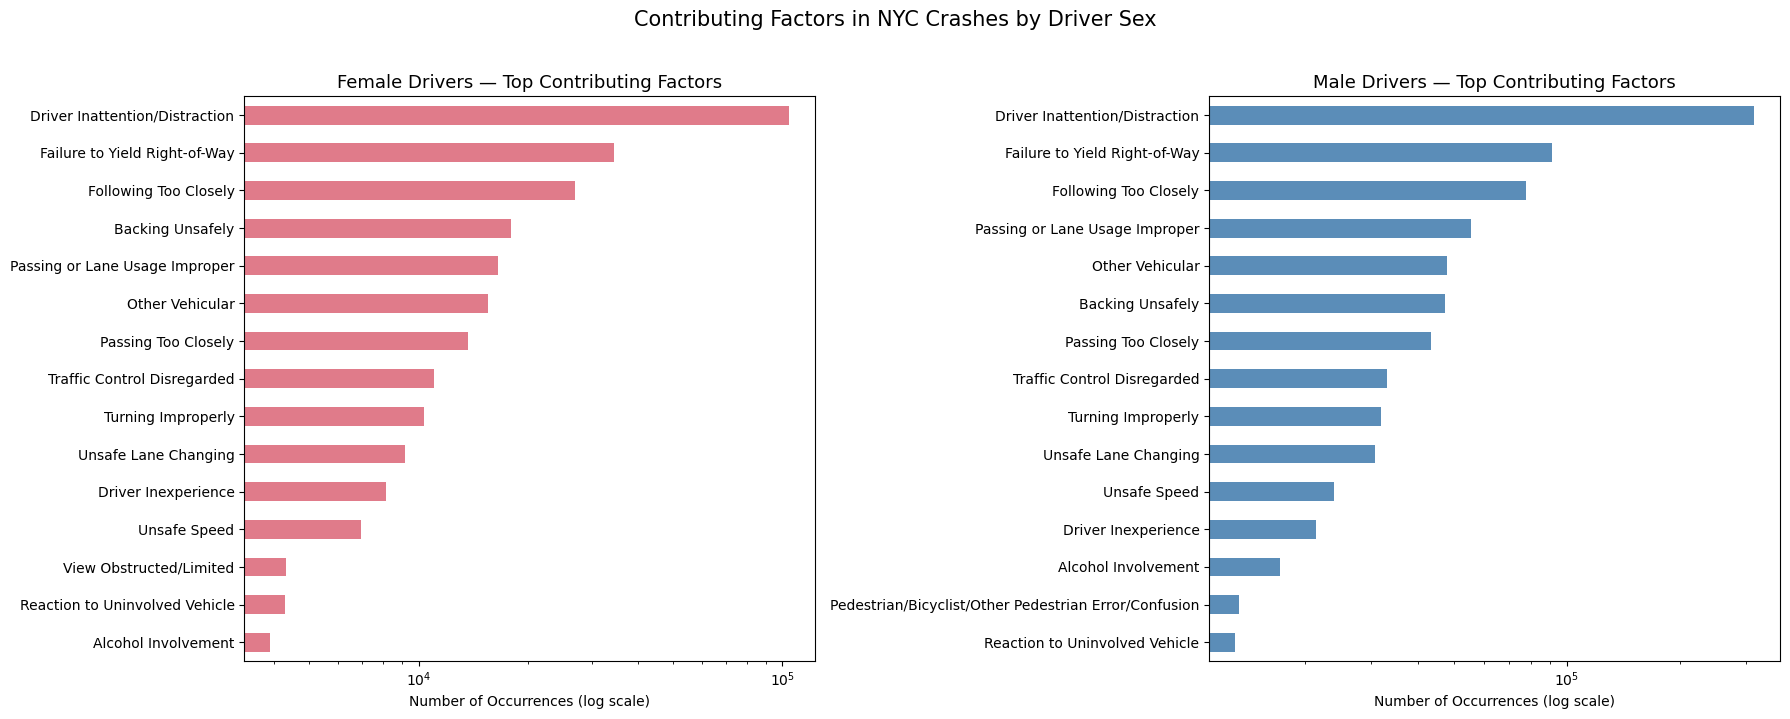

In [32]:
c_cols = [
    'c_CONTRIBUTING FACTOR VEHICLE 1', 'c_CONTRIBUTING FACTOR VEHICLE 2',
    'c_CONTRIBUTING FACTOR VEHICLE 3', 'c_CONTRIBUTING FACTOR VEHICLE 4',
    'c_CONTRIBUTING FACTOR VEHICLE 5'
]
df = crashes_with_vehicles(crash_cols=c_cols, vehicle_cols=['v_DRIVER_SEX'])

TOP_N = 15

def get_top_factors(subset, n=TOP_N):
    factors = pd.concat([subset[col] for col in c_cols])
    counts = factors.value_counts().drop('Unspecified', errors='ignore')
    return counts.head(n)

factors_f = get_top_factors(df[df['v_DRIVER_SEX'] == 'F'])
factors_m = get_top_factors(df[df['v_DRIVER_SEX'] == 'M'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

factors_f.plot(kind='barh', ax=axes[0], color='#E07B8A')
axes[0].invert_yaxis()
axes[0].set_title('Female Drivers — Top Contributing Factors', fontsize=13)
axes[0].set_xlabel('Number of Occurrences (log scale)')
axes[0].set_xscale('log')

factors_m.plot(kind='barh', ax=axes[1], color='#5B8DB8')
axes[1].invert_yaxis()
axes[1].set_title('Male Drivers — Top Contributing Factors', fontsize=13)
axes[1].set_xlabel('Number of Occurrences (log scale)')
axes[1].set_xscale('log')

plt.suptitle('Contributing Factors in NYC Crashes by Driver Sex', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Do the contributing factors depend on age?

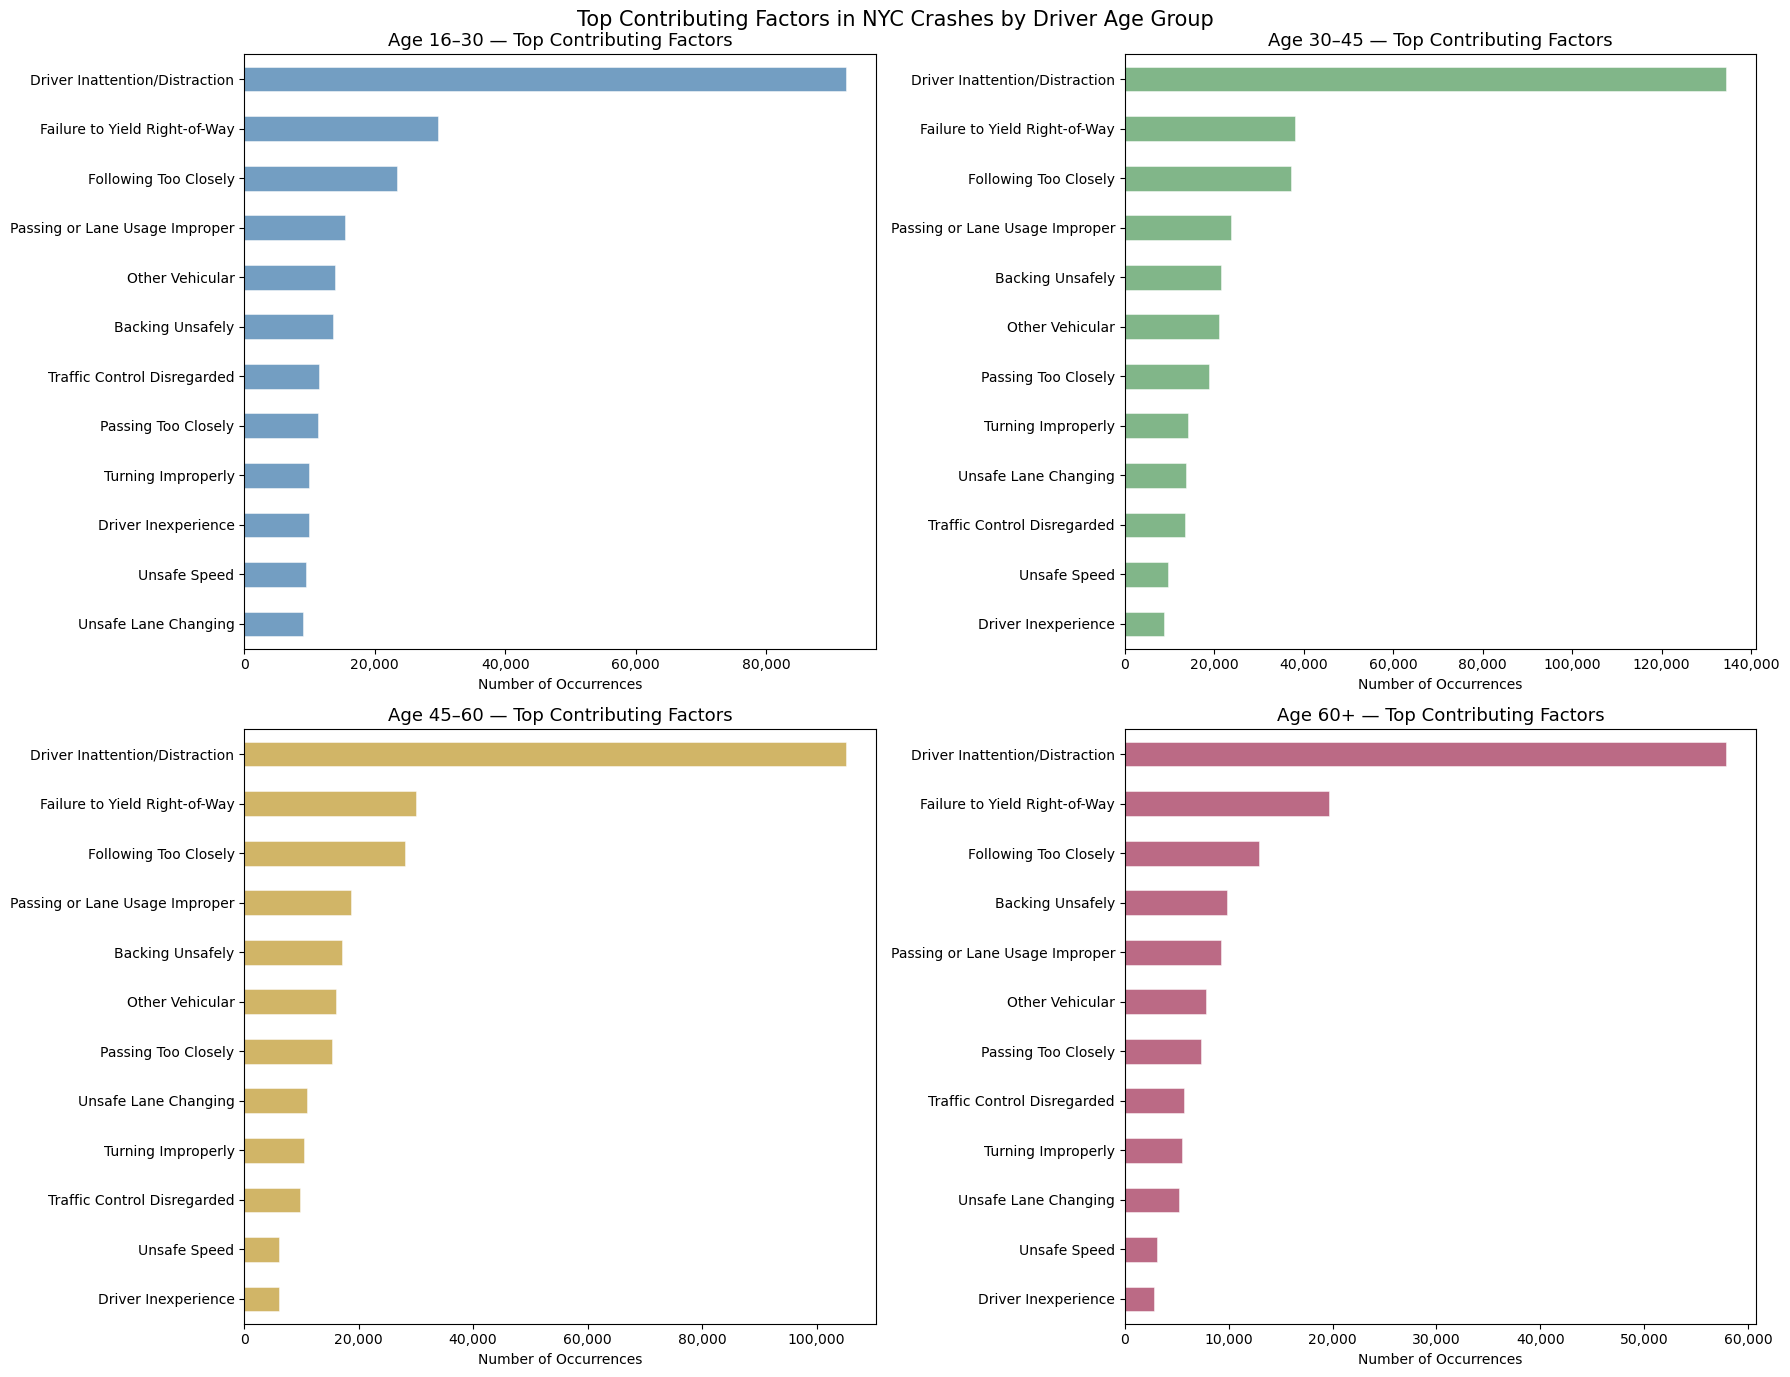

In [33]:
c_cols = [
    'c_CONTRIBUTING FACTOR VEHICLE 1', 'c_CONTRIBUTING FACTOR VEHICLE 2',
    'c_CONTRIBUTING FACTOR VEHICLE 3', 'c_CONTRIBUTING FACTOR VEHICLE 4',
    'c_CONTRIBUTING FACTOR VEHICLE 5'
]

df = crashes_with_persons(
    crash_cols=c_cols,
    person_cols=['p_PERSON_AGE', 'p_PERSON_TYPE', 'p_POSITION_IN_VEHICLE']
)

df = df[
    (df['p_PERSON_TYPE'] == 'Occupant') &
    (df['p_POSITION_IN_VEHICLE'] == 'Driver') &
    (df['p_PERSON_AGE'].between(16, 90))
].copy()

age_bins   = [16, 30, 45, 60, 91]
age_labels = ['16–30', '30–45', '45–60', '60+']
df['age_group'] = pd.cut(df['p_PERSON_AGE'], bins=age_bins, labels=age_labels,
                          right=False, include_lowest=True)

TOP_N = 12

def get_top_factors(subset, n=TOP_N):
    factors = pd.concat([subset[col] for col in c_cols])
    counts = factors.value_counts().drop('Unspecified', errors='ignore')
    return counts.head(n)

palette = ['#5B8DB8', '#6BAA75', '#C9A84C', '#B05070']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, label, color in zip(axes, age_labels, palette):
    top = get_top_factors(df[df['age_group'] == label])
    top.plot(kind='barh', ax=ax, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.invert_yaxis()
    ax.set_title(f'Age {label} — Top Contributing Factors', fontsize=13)
    ax.set_xlabel('Number of Occurrences')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Top Contributing Factors in NYC Crashes by Driver Age Group', fontsize=15)
plt.tight_layout()
plt.show()

### 2. What distracts the drivers? The weather? The people in the vehicle?

#### How does the weather affect number and seriousness of collisions?

Here we introduce the weather dataset, and include its exploratory data analysis that was performed to understand the weather conditions distributions for further analysis.

In [34]:
weather = pd.read_csv('datasets/weather.csv')
print(weather.shape)
print(weather.dtypes)
print()
print(weather.describe().to_string())

(120600, 4)
time                    str
cloud_cover_pct       int64
wind_speed_kmh      float64
precipitation_mm    float64
dtype: object

       cloud_cover_pct  wind_speed_kmh  precipitation_mm
count    120600.000000   120600.000000     120600.000000
mean         58.127886       12.400352          0.140236
std          42.009465        6.577218          0.649776
min           0.000000        0.000000          0.000000
25%           8.000000        7.600000          0.000000
50%          75.000000       11.200000          0.000000
75%         100.000000       16.100000          0.000000
max         100.000000       60.600000         33.800000


To create levels from the cloud coverage distribution we follow a practice mentioned on wikipedia:

"Oktas are often referenced in aviation weather forecasts and low level forecasts: SKC = Sky clear (0 oktas); FEW = Few (1 to 2 oktas); SCT = Scattered (3 to 4 oktas); BKN = Broken (5 to 7 oktas); OVC = Overcast (8 oktas)"

The plot below shows the weather conditions distributions along with the proposed levels - the different levels of the precipitation, wind speed and cloud coverage do not contain equal number of observations, but they realistically represent different strengths of the weather condition, what in our opinion is more meaningful for the analysis.

Precipitation levels (mm):
  None                    [0, 0.1)
  Light                   [0.1, 2.5)
  Moderate                [2.5, 7.6)
  Heavy                   [7.6, ∞)

Wind Speed levels (km/h):
  Calm                    [0, 20)
  Moderate                [20, 40)
  Strong                  [40, 61)
  Storm                   [61, ∞)

Cloud Coverage levels (%):
  SKC (clear)             [0, 6.25)
  FEW (1-2 oktas)         [6.25, 31.25)
  SCT (3-4 oktas)         [31.25, 56.25)
  BKN (5-7 oktas)         [56.25, 93.75)
  OVC (8 oktas)           [93.75, 100)



/var/folders/tb/jb06w8hn5r72136sx1ztbxnr0000gn/T/ipykernel_61275/1389294746.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


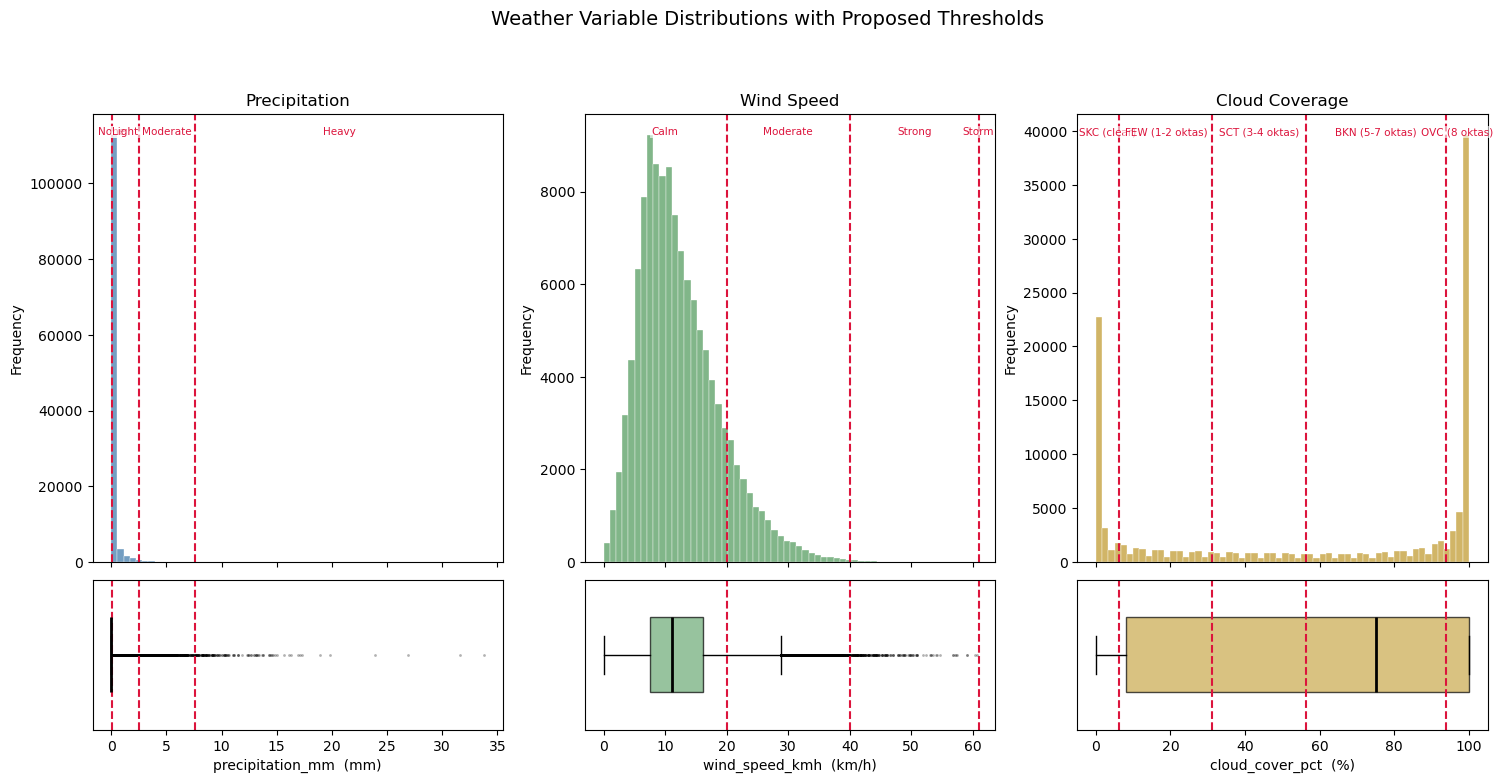

In [35]:
precip_col = 'precipitation_mm'
wind_col   = 'wind_speed_kmh'
cloud_col  = 'cloud_cover_pct'

# 1 okta = 12.5%;  group boundaries at 0.5 / 2.5 / 4.5 / 7.5 oktas → %
thresholds = {
    precip_col: {
        'label': 'Precipitation',
        'cuts': [0.1, 2.5, 7.6],
        'labels': ['None', 'Light', 'Moderate', 'Heavy'],
        'bins_full': [0, 0.1, 2.5, 7.6, np.inf],
        'unit': 'mm'
    },
    wind_col: {
        'label': 'Wind Speed',
        'cuts': [20, 40, 61],
        'labels': ['Calm', 'Moderate', 'Strong', 'Storm'],
        'bins_full': [0, 20, 40, 61, np.inf],
        'unit': 'km/h'
    },
    cloud_col: {
        'label': 'Cloud Coverage',
        'cuts': [6.25, 31.25, 56.25, 93.75],   # 0.5 / 2.5 / 4.5 / 7.5 oktas → %
        'labels': ['SKC (clear)', 'FEW (1-2 oktas)', 'SCT (3-4 oktas)',
                   'BKN (5-7 oktas)', 'OVC (8 oktas)'],
        'bins_full': [0, 6.25, 31.25, 56.25, 93.75, 100],
        'unit': '%'
    },
}

colors = {'precipitation_mm': '#5B8DB8', 'wind_speed_kmh': '#6BAA75', 'cloud_cover_pct': '#C9A84C'}

fig, axes = plt.subplots(2, 3, figsize=(18, 8),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.06})

for j, col in enumerate([precip_col, wind_col, cloud_col]):
    data  = weather[col].dropna()
    meta  = thresholds[col]
    color = colors[col]
    ax_h  = axes[0, j]
    ax_b  = axes[1, j]

    # histogram
    ax_h.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
    for cut in meta['cuts']:
        ax_h.axvline(cut, color='crimson', linestyle='--', linewidth=1.5)
    ax_h.set_title(meta['label'], fontsize=12)
    ax_h.set_ylabel('Frequency')
    ax_h.tick_params(labelbottom=False)

    # annotate band labels near top
    boundaries = [data.min()] + meta['cuts'] + [data.max()]
    ymax = ax_h.get_ylim()[1]
    for i, lbl in enumerate(meta['labels']):
        mid = (boundaries[i] + boundaries[i + 1]) / 2
        ax_h.text(mid, ymax * 0.97, lbl, ha='center', va='top',
                  fontsize=7.5, color='crimson',
                  bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

    # boxplot
    ax_b.boxplot(data, vert=False, widths=0.5,
                 patch_artist=True,
                 boxprops=dict(facecolor=color, alpha=0.7),
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for cut in meta['cuts']:
        ax_b.axvline(cut, color='crimson', linestyle='--', linewidth=1.5)
    ax_b.set_xlabel(f'{col}  ({meta["unit"]})')
    ax_b.set_yticks([])

    # print proposed levels
    print(f'{meta["label"]} levels ({meta["unit"]}):')
    bins = meta['bins_full']
    for i, lbl in enumerate(meta['labels']):
        hi = bins[i + 1] if bins[i + 1] != np.inf else '∞'
        print(f'  {lbl:22s}  [{bins[i]}, {hi})')
    print()

plt.suptitle('Weather Variable Distributions with Proposed Thresholds', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The next two cells combine the weather data with collisions hourly (the weather condition level is associated with a crash based on the rounded hour of the crash) and visualize the distributions of total crashes, serious crashes (at least 1 person injured or killed) and serious injury rate for all levels of the weather conditions. These plots enable us to understand if and how the weather affects the collisions.

In [36]:
crashes = crash_df[[
    'c_CRASH DATE', 'c_CRASH TIME',
    'c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'
]].reset_index()  # brings c_COLLISION_ID back as a plain column

# c_CRASH DATE is stored as datetime in parquet — extract date string before combining
crashes['datetime'] = pd.to_datetime(
    pd.to_datetime(crashes['c_CRASH DATE']).dt.strftime('%Y-%m-%d') + ' ' + crashes['c_CRASH TIME'].astype(str),
    format='mixed', errors='coerce'
).dt.floor('h')

# round weather time to hour as well
weather['datetime'] = pd.to_datetime(weather['time']).dt.floor('h')

# merge
merged = crashes.merge(weather, on='datetime', how='left')

# --- assign level columns using the thresholds defined above ---
merged['precip_level'] = pd.cut(
    merged['precipitation_mm'],
    bins=[0, 0.1, 2.5, 7.6, np.inf],
    labels=['None', 'Light', 'Moderate', 'Heavy'],
    include_lowest=True
)
merged['wind_level'] = pd.cut(
    merged['wind_speed_kmh'],
    bins=[0, 20, 40, 61, np.inf],
    labels=['Calm', 'Moderate', 'Strong', 'Storm'],
    include_lowest=True
)
merged['cloud_level'] = pd.cut(
    merged['cloud_cover_pct'],
    bins=[0, 6.25, 31.25, 56.25, 93.75, 100],
    labels=['SKC', 'FEW', 'SCT', 'BKN', 'OVC'],
    include_lowest=True
)

merged['is_serious'] = (
    (merged['c_NUMBER OF PERSONS INJURED'] > 0) |
    (merged['c_NUMBER OF PERSONS KILLED'] > 0)
)

print(f"Total crashes      : {len(merged):,}")
print(f"Weather matched    : {merged['precipitation_mm'].notna().sum():,}")
print(f"Serious crashes    : {merged['is_serious'].sum():,}")
print()
print("Precipitation level counts:\n", merged['precip_level'].value_counts().sort_index())
print("\nWind level counts:\n",         merged['wind_level'].value_counts().sort_index())
print("\nCloud level counts:\n",        merged['cloud_level'].value_counts().sort_index())

Total crashes      : 1,527,549
Weather matched    : 1,527,549
Serious crashes    : 368,546

Precipitation level counts:
 precip_level
None        1330584
Light        175360
Moderate      20173
Heavy          1432
Name: count, dtype: int64

Wind level counts:
 wind_level
Calm        1314944
Moderate     209999
Strong         2606
Storm             0
Name: count, dtype: int64

Cloud level counts:
 cloud_level
SKC    331137
FEW    179206
SCT    146173
BKN    267711
OVC    603322
Name: count, dtype: int64


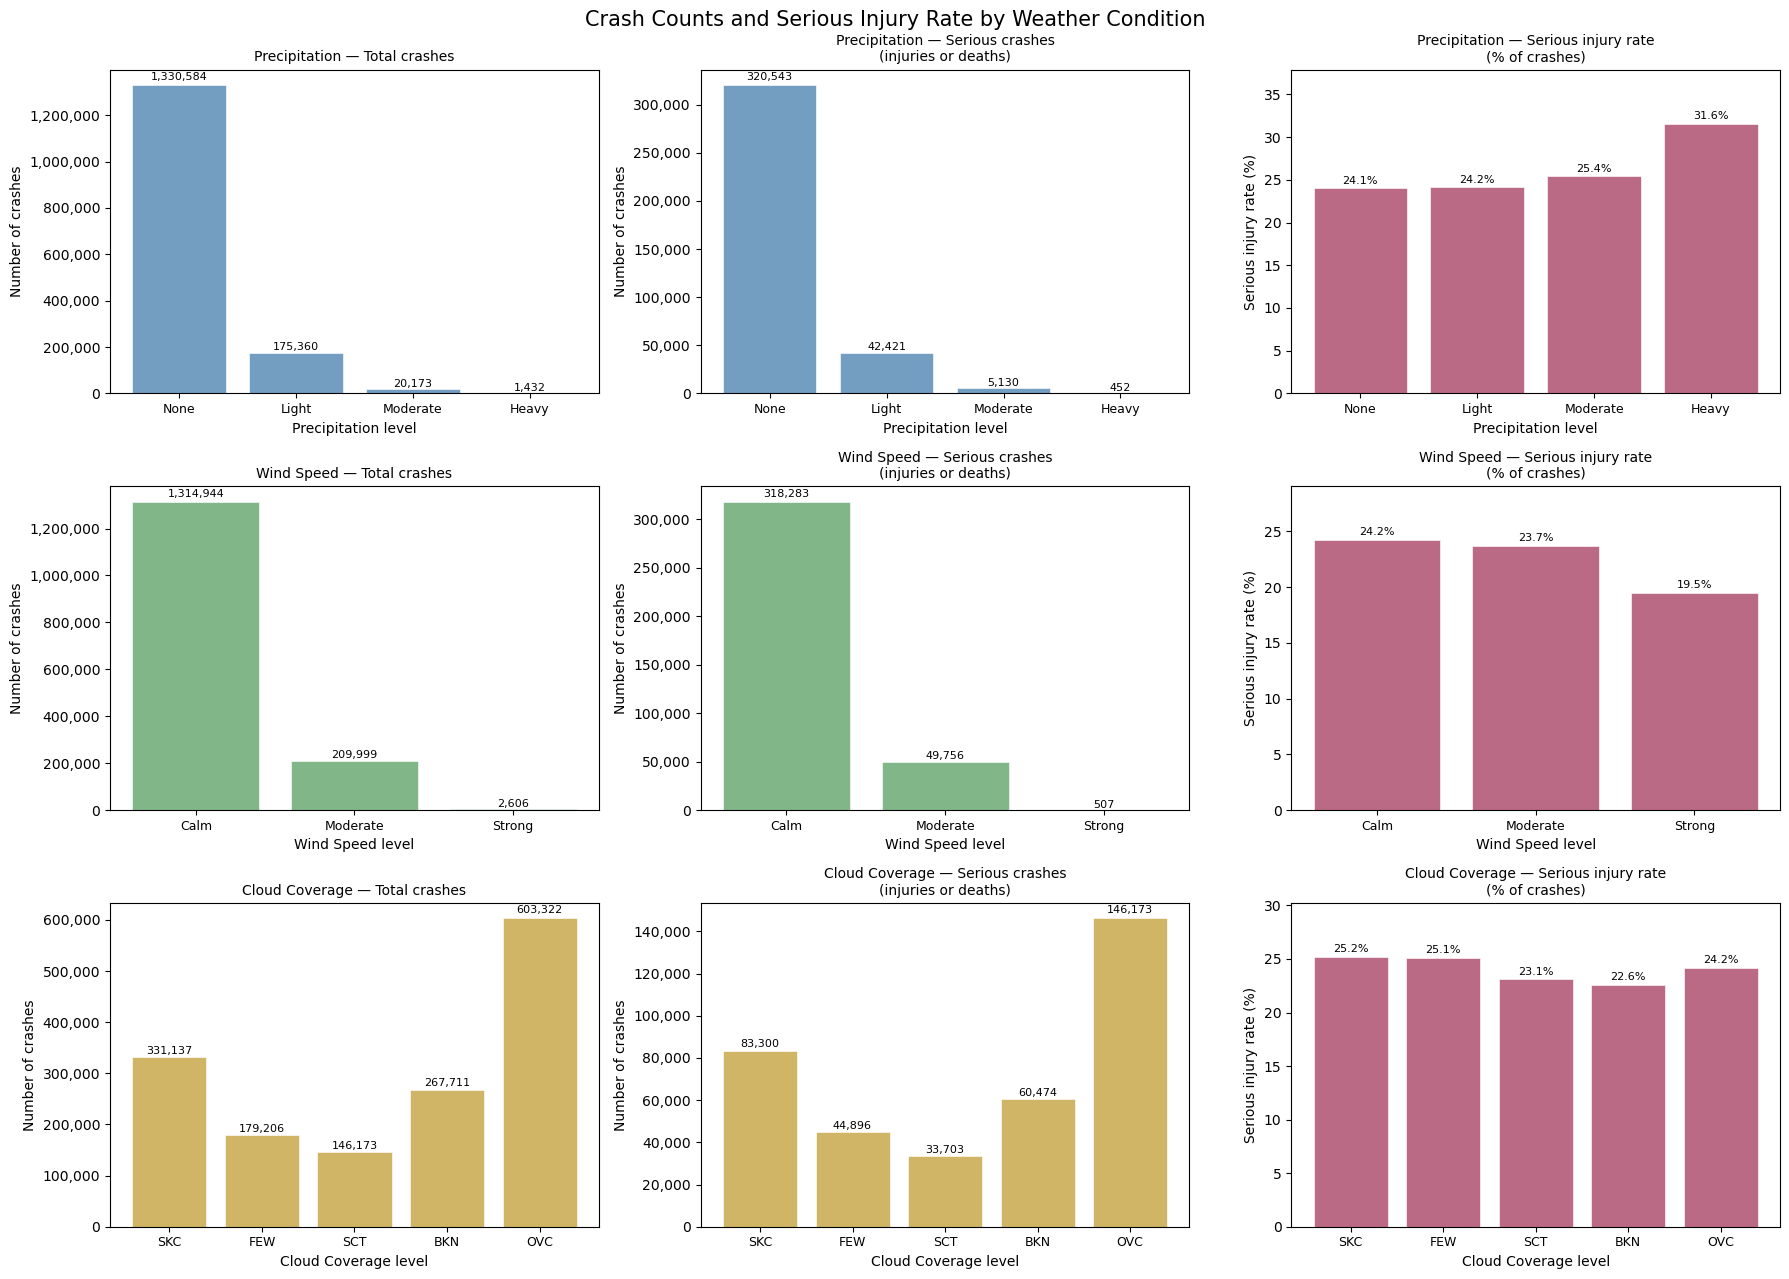

In [37]:
conditions = [
    ('precip_level', 'Precipitation',  ['None', 'Light', 'Moderate', 'Heavy'],  '#5B8DB8'),
    ('wind_level',   'Wind Speed',     ['Calm', 'Moderate', 'Strong', 'Storm'], '#6BAA75'),
    ('cloud_level',  'Cloud Coverage', ['SKC', 'FEW', 'SCT', 'BKN', 'OVC'],    '#C9A84C'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Crash Counts and Serious Injury Rate by Weather Condition', fontsize=15)

for i, (col, label, order, color) in enumerate(conditions):
    total    = merged.groupby(col, observed=True).size().reindex(order)
    serious  = merged[merged['is_serious']].groupby(col, observed=True).size().reindex(order)
    rate     = (serious / total * 100).round(1)

    for j, (data, subtitle, fmt) in enumerate([
        (total,   'Total crashes',                        '{:,.0f}'),
        (serious, 'Serious crashes\n(injuries or deaths)', '{:,.0f}'),
        (rate,    'Serious injury rate\n(% of crashes)',   '{:.1f}%'),
    ]):
        ax = axes[i, j]
        bar_color = color if j < 2 else '#B05070'
        bars = ax.bar(order, data, color=bar_color, alpha=0.85, edgecolor='white', linewidth=0.5)

        for bar, val in zip(bars, data):
            if pd.notna(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                        fmt.format(val), ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{label} — {subtitle}', fontsize=10)
        ax.set_xlabel(f'{label} level')
        ax.tick_params(axis='x', labelsize=9)

        if j < 2:
            ax.set_ylabel('Number of crashes')
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        else:
            ax.set_ylabel('Serious injury rate (%)')
            ax.set_ylim(0, max(rate.max() * 1.2, 1))

plt.tight_layout()
plt.show()

#### Does the number of vehicle occupants affect the collisions? Are we safer in a group or more distracted?

Occupants  |  Total vehicles  |  Serious  |  Rate %
     1     |     1,014,749  |  295,575  |  29.1%
     2     |       202,035  |   70,738  |  35.0%
     3     |        56,278  |   22,701  |  40.3%
     4     |        22,150  |    8,429  |  38.1%
     5     |         7,929  |    2,956  |  37.3%
     6     |         2,765  |      861  |  31.1%
     7     |         1,247  |      353  |  28.3%
     8     |           811  |      195  |  24.0%
    9+     |         3,321  |      643  |  19.4%


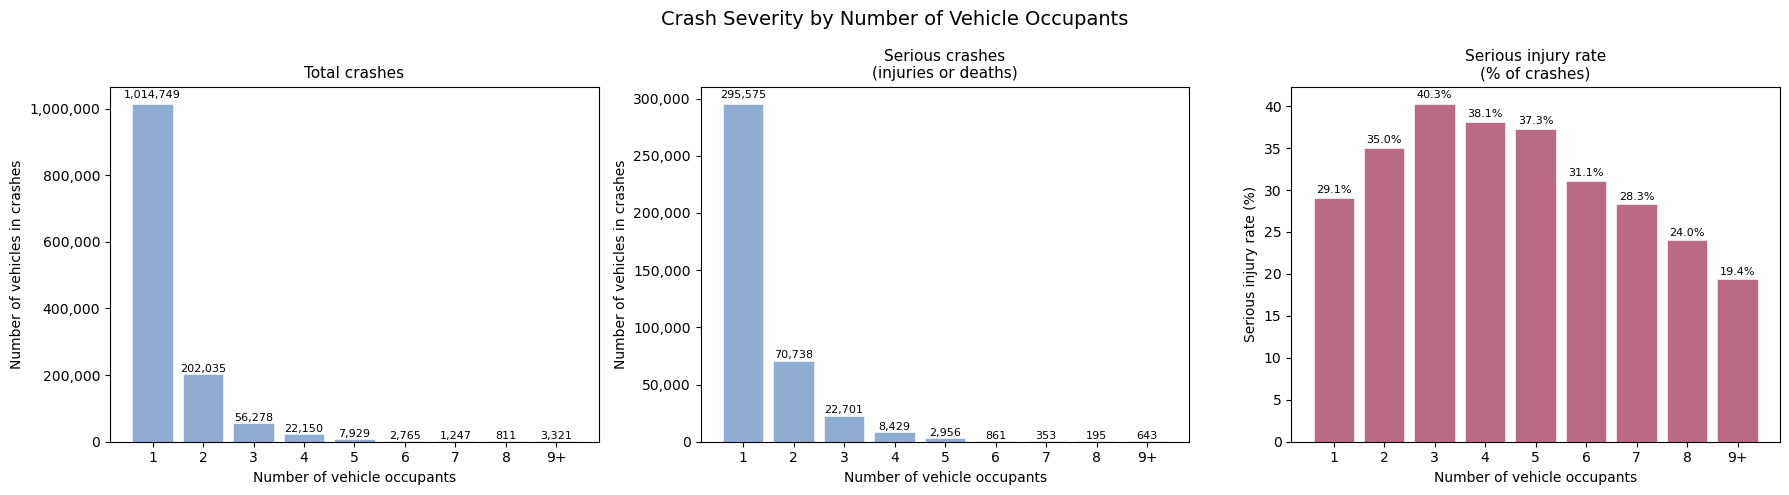

In [38]:
occ_df = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_VEHICLE_OCCUPANTS']
)

# drop rows with missing/zero occupants (unreported)
occ_df = occ_df[occ_df['v_VEHICLE_OCCUPANTS'] > 0].copy()

# cap at 9+ to keep x-axis readable (buses etc. are outliers)
MAX_OCC = 9
occ_df['occ_group'] = occ_df['v_VEHICLE_OCCUPANTS'].clip(upper=MAX_OCC).astype(int)
order = list(range(1, MAX_OCC)) + [MAX_OCC]
labels = [str(n) for n in range(1, MAX_OCC)] + [f'{MAX_OCC}+']

occ_df['is_serious'] = (
    (occ_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (occ_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

total   = occ_df.groupby('occ_group').size().reindex(order)
serious = occ_df[occ_df['is_serious']].groupby('occ_group').size().reindex(order)
rate    = (serious / total * 100).round(1)

print("Occupants  |  Total vehicles  |  Serious  |  Rate %")
for n, lbl in zip(order, labels):
    print(f"  {lbl:>4s}     |  {int(total[n]):>12,}  |  {int(serious[n]):>7,}  |  {rate[n]:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Crash Severity by Number of Vehicle Occupants', fontsize=14)

for ax, (data, subtitle, color, fmt, ylabel) in zip(axes, [
    (total,   'Total crashes',                        '#7B9EC9', '{:,.0f}', 'Number of vehicles in crashes'),
    (serious, 'Serious crashes\n(injuries or deaths)', '#7B9EC9', '{:,.0f}', 'Number of vehicles in crashes'),
    (rate,    'Serious injury rate\n(% of crashes)',   '#B05070', '{:.1f}%', 'Serious injury rate (%)'),
]):
    bars = ax.bar(labels, data.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, data.values):
        if pd.notna(val) and val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    fmt.format(val), ha='center', va='bottom', fontsize=8)
    ax.set_title(subtitle, fontsize=11)
    ax.set_xlabel('Number of vehicle occupants')
    ax.set_ylabel(ylabel)
    if 'rate' not in subtitle.lower():
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

The serious injury rate increases for 3-5 vehicle occupants, which may mean that regular cars with up to 5 seats that are carrying multiple people, even though take up a significantly smaller part of the total crashes, are likely to be involved in a more serious collision once involved at all.

### 3. Deeper investigation into the relationship between the seriousness of the crashes and the number of vehicle occupants.
#### When people are travelling in groups more? Does weather have an influence on that?

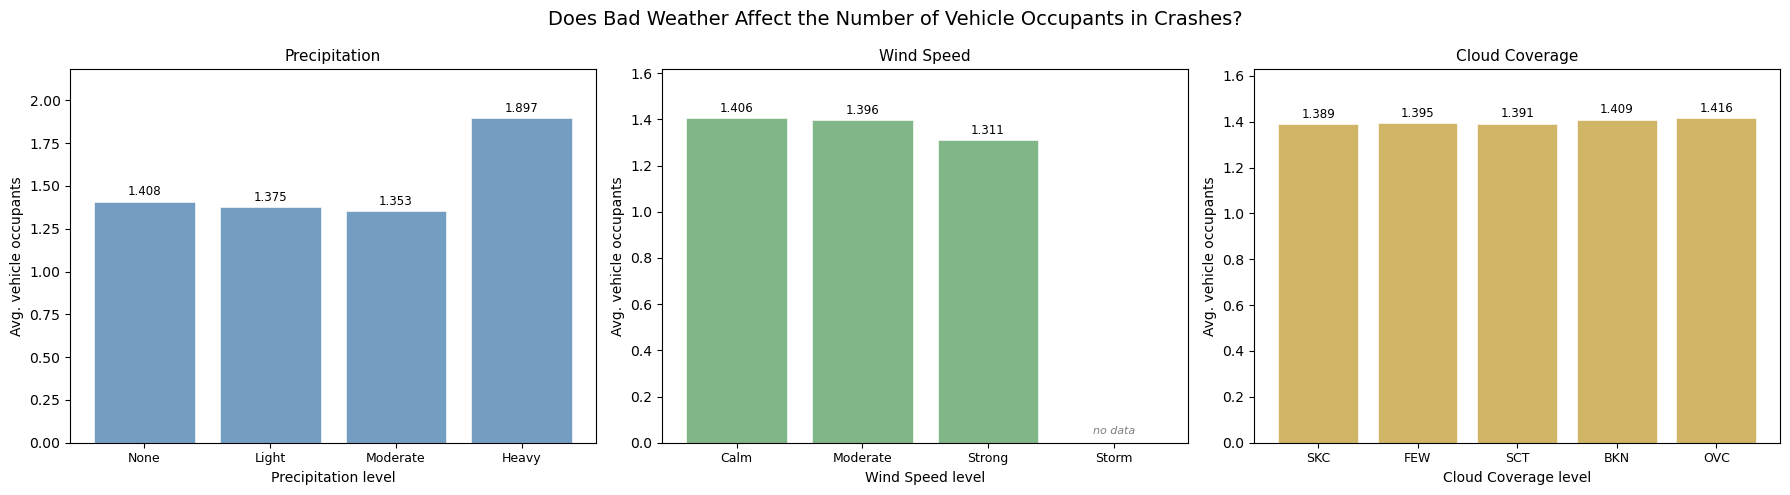

In [39]:
# join vehicle occupants with weather levels already assigned in `merged`
occ_weather = (
    crashes_with_vehicles(vehicle_cols=['v_VEHICLE_OCCUPANTS'])
    .query('v_VEHICLE_OCCUPANTS > 0')
    .merge(merged[['c_COLLISION_ID', 'precip_level', 'wind_level', 'cloud_level']],
           on='c_COLLISION_ID', how='inner')
)

conditions = [
    ('precip_level', 'Precipitation',  ['None', 'Light', 'Moderate', 'Heavy'],  '#5B8DB8'),
    ('wind_level',   'Wind Speed',     ['Calm', 'Moderate', 'Strong', 'Storm'], '#6BAA75'),
    ('cloud_level',  'Cloud Coverage', ['SKC', 'FEW', 'SCT', 'BKN', 'OVC'],    '#C9A84C'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Does Bad Weather Affect the Number of Vehicle Occupants in Crashes?', fontsize=14)

for ax, (col, label, order, color) in zip(axes, conditions):
    means = (occ_weather.groupby(col, observed=True)['v_VEHICLE_OCCUPANTS']
             .mean().reindex(order).astype(float))
    ymax = float(np.nanmax(means.values))

    ax.bar(order, means.fillna(0).values, color=color, alpha=0.85,
           edgecolor='white', linewidth=0.5)

    for x, (cat, val) in enumerate(means.items()):
        if np.isfinite(val):
            ax.text(x, val + ymax * 0.01, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=8.5)
        else:
            ax.text(x, ymax * 0.02, 'no data',
                    ha='center', va='bottom', fontsize=8, color='gray', fontstyle='italic')

    ax.set_title(label, fontsize=11)
    ax.set_xlabel(f'{label} level')
    ax.set_ylabel('Avg. vehicle occupants')
    ax.tick_params(axis='x', labelsize=9)
    ax.set_ylim(0, ymax * 1.15)

plt.tight_layout()
plt.show()

### Who is driving the vehicles with multiple occupants?

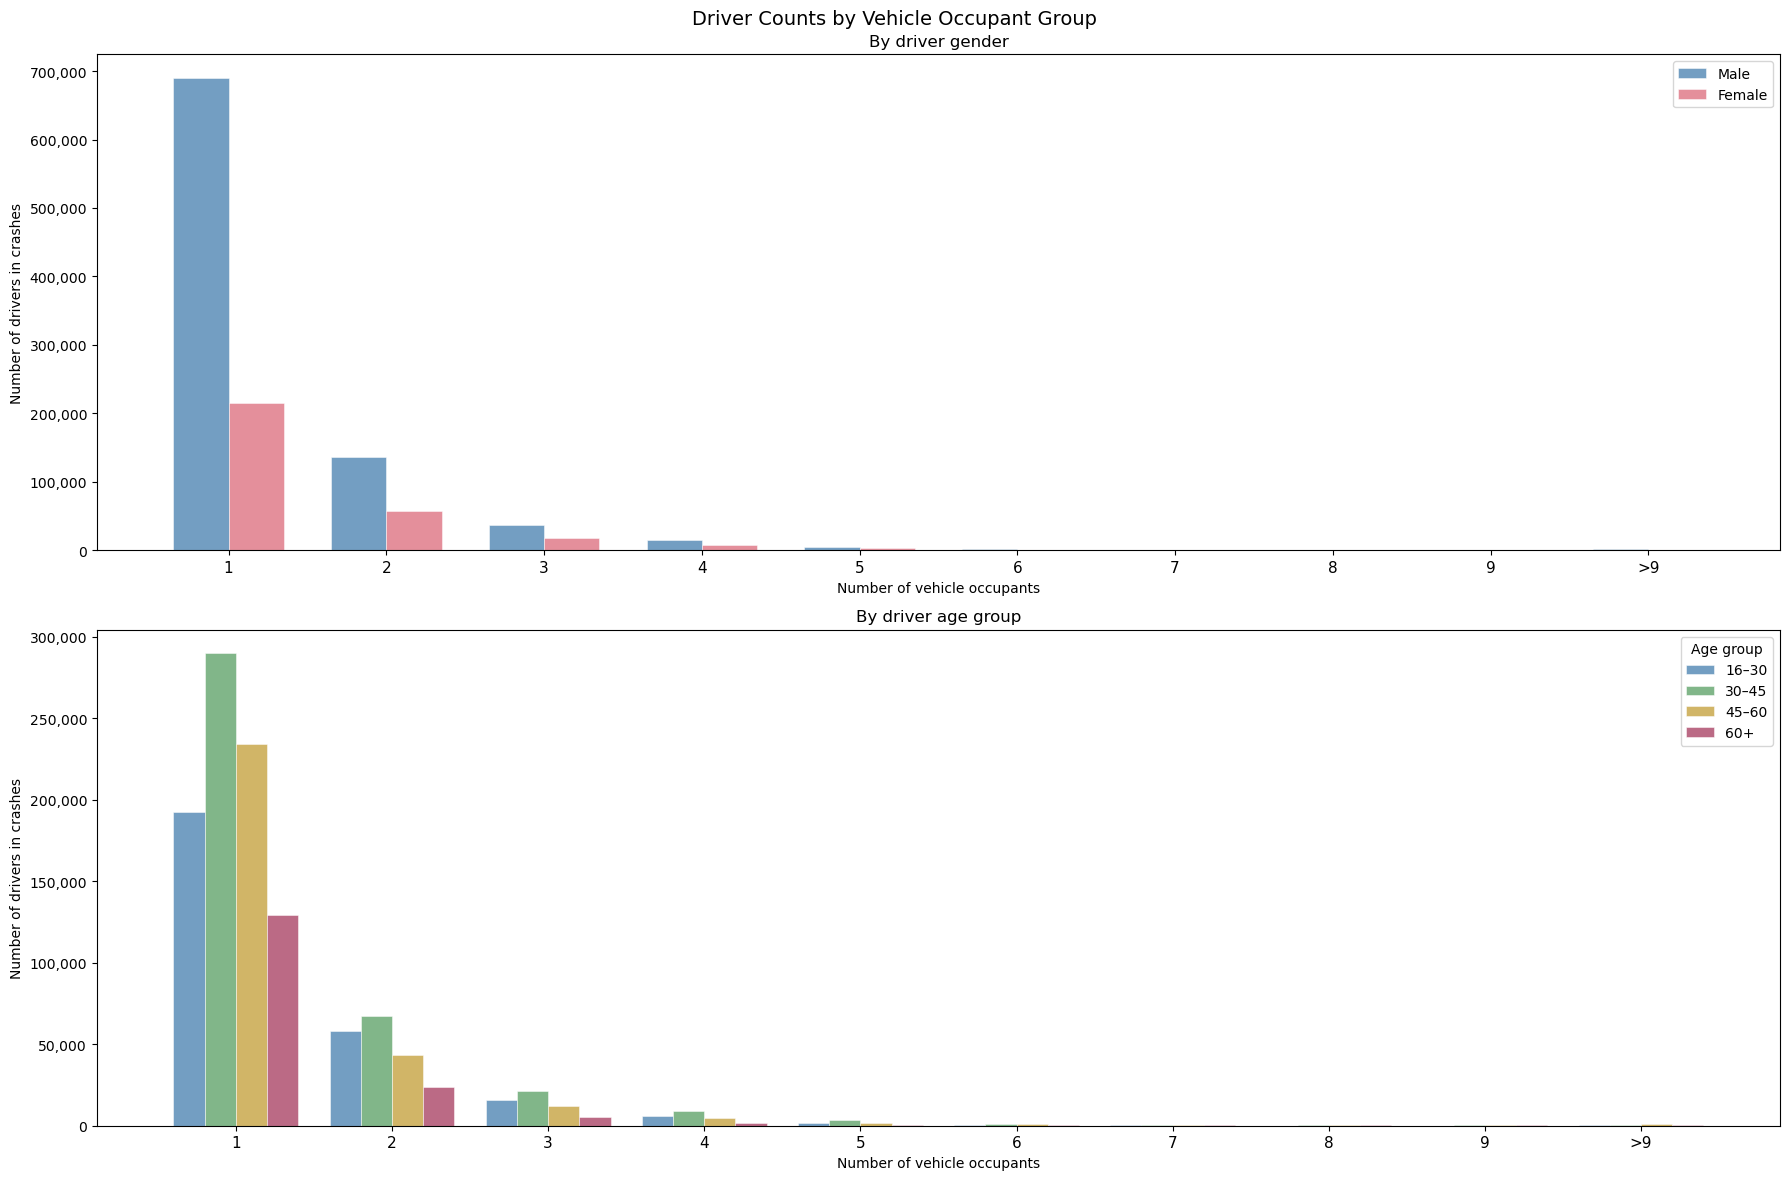

In [40]:
fmt_y  = plt.FuncFormatter(lambda x, _: f'{int(x):,}')
w      = 0.35
MAX_OCC = 9
occ_keys = list(range(1, MAX_OCC + 1)) + [MAX_OCC + 1]
occ_lbl  = [str(n) for n in range(1, MAX_OCC + 1)] + ['>9']

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('Driver Counts by Vehicle Occupant Group', fontsize=14)

# ---- Plot 1: occupants × gender ----
occ_sex = crashes_with_vehicles(vehicle_cols=['v_VEHICLE_OCCUPANTS', 'v_DRIVER_SEX'])
occ_sex = occ_sex[
    (occ_sex['v_VEHICLE_OCCUPANTS'] > 0) &
    (occ_sex['v_DRIVER_SEX'].isin(['M', 'F']))
].copy()
occ_sex['occ_group'] = occ_sex['v_VEHICLE_OCCUPANTS'].apply(lambda x: x if x <= MAX_OCC else MAX_OCC + 1)

occ_counts = (occ_sex.groupby(['occ_group', 'v_DRIVER_SEX'])
              .size().unstack('v_DRIVER_SEX').reindex(occ_keys)[['M', 'F']].fillna(0))

ax = axes[0]
x = np.arange(len(occ_keys))
ax.bar(x - w/2, occ_counts['M'], w, label='Male',   color='#5B8DB8', alpha=0.85, edgecolor='white', linewidth=0.4)
ax.bar(x + w/2, occ_counts['F'], w, label='Female', color='#E07B8A', alpha=0.85, edgecolor='white', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(occ_lbl, fontsize=11)
ax.set_title('By driver gender', fontsize=12)
ax.set_xlabel('Number of vehicle occupants')
ax.set_ylabel('Number of drivers in crashes')
ax.yaxis.set_major_formatter(fmt_y)
ax.legend(fontsize=10)

# ---- Plot 2: occupants × age group ----
occ_age = vehicles_with_persons(
    vehicle_cols=['v_VEHICLE_OCCUPANTS'],
    person_cols=['p_PERSON_AGE', 'p_PERSON_TYPE', 'p_POSITION_IN_VEHICLE']
)
occ_age = occ_age[
    (occ_age['v_VEHICLE_OCCUPANTS'] > 0) &
    (occ_age['p_PERSON_TYPE'] == 'Occupant') &
    (occ_age['p_POSITION_IN_VEHICLE'] == 'Driver') &
    (occ_age['p_PERSON_AGE'].between(16, 90))
].copy()
occ_age['occ_group'] = occ_age['v_VEHICLE_OCCUPANTS'].apply(lambda x: x if x <= MAX_OCC else MAX_OCC + 1)

age_bins   = [16, 30, 45, 60, 91]
age_labels = ['16–30', '30–45', '45–60', '60+']
age_colors = ['#5B8DB8', '#6BAA75', '#C9A84C', '#B05070']
occ_age['age_group'] = pd.cut(occ_age['p_PERSON_AGE'], bins=age_bins, labels=age_labels,
                               right=False, include_lowest=True)

age_counts = (occ_age.groupby(['occ_group', 'age_group'], observed=True)
              .size().unstack('age_group').reindex(occ_keys)[age_labels].fillna(0))

ax = axes[1]
n_groups = len(age_labels)
bar_w = 0.8 / n_groups
x = np.arange(len(occ_keys))
offsets = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * bar_w

for lbl, color, offset in zip(age_labels, age_colors, offsets):
    ax.bar(x + offset, age_counts[lbl], bar_w, label=lbl,
           color=color, alpha=0.85, edgecolor='white', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(occ_lbl, fontsize=11)
ax.set_title('By driver age group', fontsize=12)
ax.set_xlabel('Number of vehicle occupants')
ax.set_ylabel('Number of drivers in crashes')
ax.yaxis.set_major_formatter(fmt_y)
ax.legend(fontsize=10, title='Age group')

plt.tight_layout()
plt.show()

#### How many people get injured or die in a crashes involving a vehicle with multiple occupants?

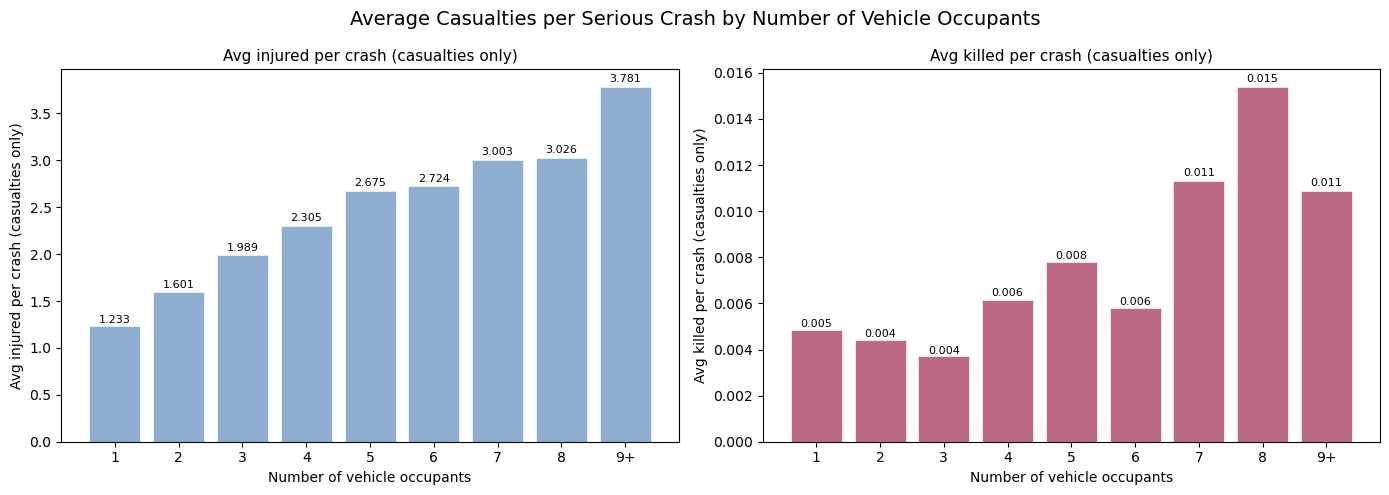

In [36]:
occ_cas = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_VEHICLE_OCCUPANTS']
)

occ_cas = occ_cas[occ_cas['v_VEHICLE_OCCUPANTS'] > 0].copy()

# keep only crashes with at least one casualty
occ_cas = occ_cas[
    (occ_cas['c_NUMBER OF PERSONS INJURED'] > 0) |
    (occ_cas['c_NUMBER OF PERSONS KILLED'] > 0)
].copy()

MAX_OCC = 9
occ_cas['occ_group'] = occ_cas['v_VEHICLE_OCCUPANTS'].clip(upper=MAX_OCC).astype(int)
order  = list(range(1, MAX_OCC)) + [MAX_OCC]
labels = [str(n) for n in range(1, MAX_OCC)] + [f"{MAX_OCC}+"]

avg_inj  = occ_cas.groupby('occ_group')['c_NUMBER OF PERSONS INJURED'].mean().reindex(order)
avg_kill = occ_cas.groupby('occ_group')['c_NUMBER OF PERSONS KILLED'].mean().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Average Casualties per Serious Crash by Number of Vehicle Occupants', fontsize=14)

for ax, (data, subtitle, color) in zip(axes, [
    (avg_inj,  'Avg injured per crash (casualties only)',  '#7B9EC9'),
    (avg_kill, 'Avg killed per crash (casualties only)',   '#B05070'),
]):
    bars = ax.bar(labels, data.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, data.values):
        if pd.notna(val) and val >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f"{val:.3f}", ha='center', va='bottom', fontsize=8)
    ax.set_title(subtitle, fontsize=11)
    ax.set_xlabel('Number of vehicle occupants')
    ax.set_ylabel(subtitle)

plt.tight_layout()
plt.show()

### 4. Other data-driven questions for potential story building
#### Older vehicles = more crashes / deadlier crashes?

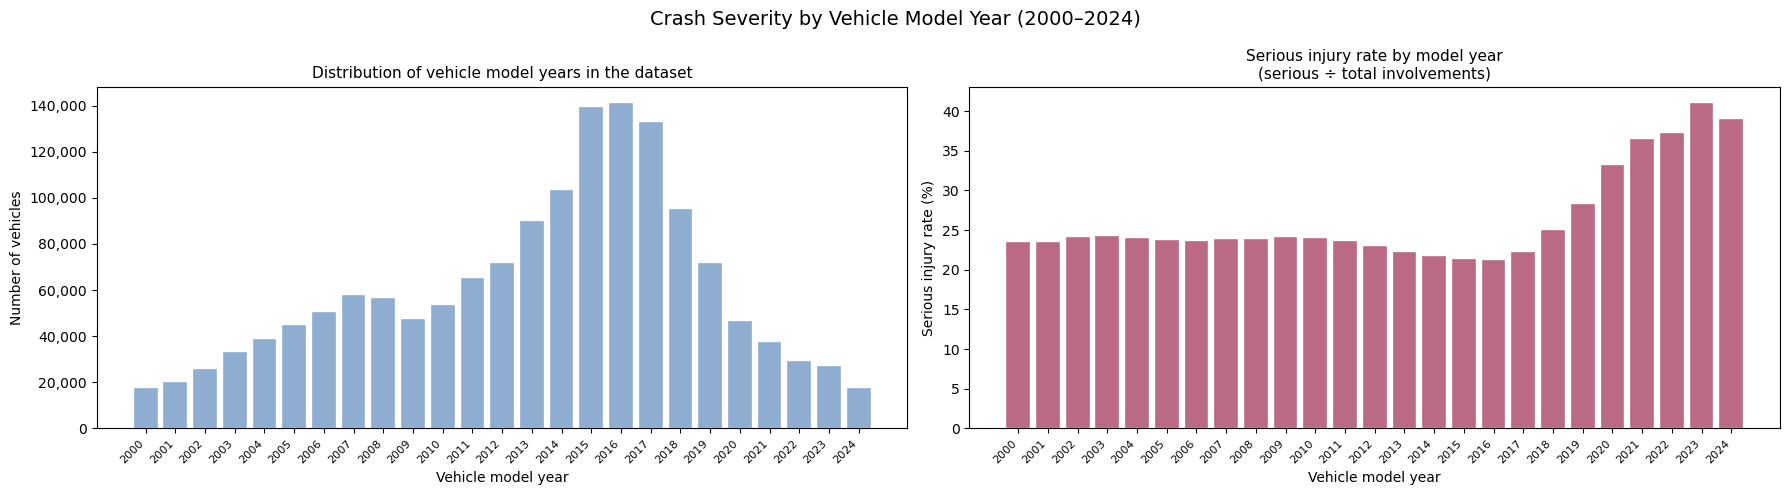

In [ ]:
yr_df = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_VEHICLE_YEAR']
)

YEAR_MIN, YEAR_MAX = 2000, 2025
yr_df = yr_df[yr_df['v_VEHICLE_YEAR'].between(YEAR_MIN, YEAR_MAX)].copy()

yr_df['is_serious'] = (
    (yr_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (yr_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

years   = list(range(YEAR_MIN, YEAR_MAX + 1))
total   = yr_df.groupby('v_VEHICLE_YEAR').size().reindex(years, fill_value=0)
serious = yr_df[yr_df['is_serious']].groupby('v_VEHICLE_YEAR').size().reindex(years, fill_value=0)
rate    = (serious / total.replace(0, np.nan) * 100).round(2)

xtick_kw = dict(rotation=45, ha='right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Crash Severity by Vehicle Model Year (2000–2025)', fontsize=14)

# left: distribution of vehicle years in the dataset
axes[0].bar(years, total.values, color='#7B9EC9', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution of vehicle model years in the dataset', fontsize=11)
axes[0].set_xlabel('Vehicle model year')
axes[0].set_ylabel('Number of vehicles')
axes[0].set_xticks(years)
axes[0].set_xticklabels([str(y) for y in years], **xtick_kw)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# right: serious injury rate — normalised, fleet-size-neutral
axes[1].bar(years, rate.values, color='#B05070', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].set_title('Serious injury rate by model year\n(serious ÷ total involvements)', fontsize=11)
axes[1].set_xlabel('Vehicle model year')
axes[1].set_ylabel('Serious injury rate (%)')
axes[1].set_xticks(years)
axes[1].set_xticklabels([str(y) for y in years], **xtick_kw)

plt.tight_layout()
plt.show()

#### Who drives the cars from the period 2013-2019?

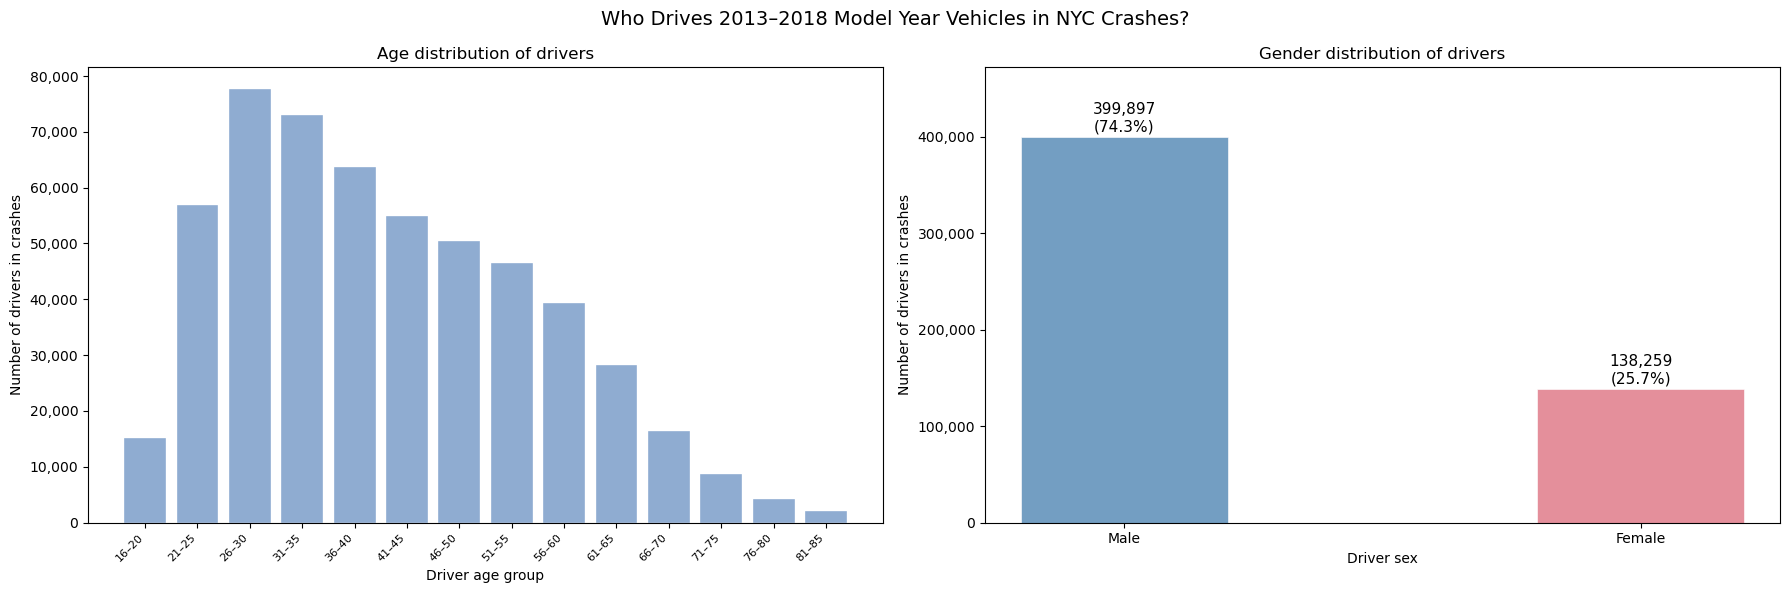

In [42]:
df = vehicles_with_persons(
    vehicle_cols=['v_VEHICLE_YEAR', 'v_DRIVER_SEX'],
    person_cols=['p_PERSON_AGE', 'p_PERSON_TYPE', 'p_POSITION_IN_VEHICLE']
)

df = df[
    (df['v_VEHICLE_YEAR'].between(2013, 2018)) &
    (df['p_PERSON_TYPE'] == 'Occupant') &
    (df['p_POSITION_IN_VEHICLE'] == 'Driver') &
    (df['p_PERSON_AGE'].between(16, 90)) &
    (df['v_DRIVER_SEX'].isin(['M', 'F']))
].copy()

bin_edges  = list(range(16, 91, 5))
bin_labels = [f'{lo}–{lo+4}' for lo in bin_edges[:-1]]
df['age_group'] = pd.cut(df['p_PERSON_AGE'], bins=bin_edges, labels=bin_labels,
                          right=False, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Who Drives 2013–2018 Model Year Vehicles in NYC Crashes?', fontsize=14)

# --- age distribution ---
age_counts = df['age_group'].value_counts().reindex(bin_labels, fill_value=0)
axes[0].bar(bin_labels, age_counts.values, color='#7B9EC9', alpha=0.85,
            edgecolor='white', linewidth=0.3)
axes[0].set_title('Age distribution of drivers', fontsize=12)
axes[0].set_xlabel('Driver age group')
axes[0].set_ylabel('Number of drivers in crashes')
axes[0].set_xticks(range(len(bin_labels)))
axes[0].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- gender distribution ---
sex_counts = df['v_DRIVER_SEX'].value_counts().reindex(['M', 'F'])
sex_labels = ['Male', 'Female']
sex_colors = ['#5B8DB8', '#E07B8A']
total      = sex_counts.sum()

bars = axes[1].bar(sex_labels, sex_counts.values, color=sex_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5, width=0.4)
for bar, val in zip(bars, sex_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.005,
                 f'{val:,}\n({val / total * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Gender distribution of drivers', fontsize=12)
axes[1].set_xlabel('Driver sex')
axes[1].set_ylabel('Number of drivers in crashes')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_ylim(0, sex_counts.max() * 1.18)

plt.tight_layout()
plt.show()

#### Who drives the vehicles from the period 2019-2025?

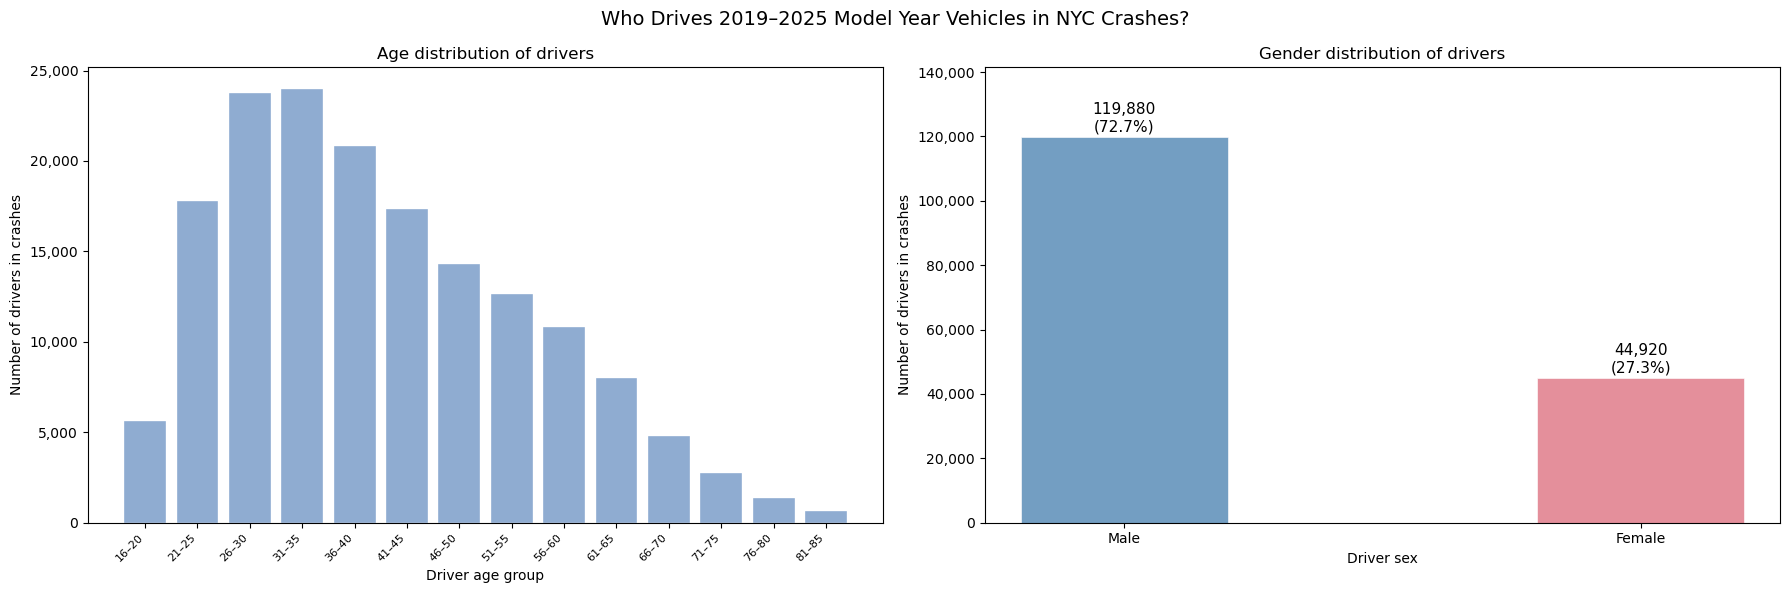

In [37]:
df = vehicles_with_persons(
    vehicle_cols=['v_VEHICLE_YEAR', 'v_DRIVER_SEX'],
    person_cols=['p_PERSON_AGE', 'p_PERSON_TYPE', 'p_POSITION_IN_VEHICLE']
)

df = df[
    (df['v_VEHICLE_YEAR'].between(2019, 2025)) &
    (df['p_PERSON_TYPE'] == 'Occupant') &
    (df['p_POSITION_IN_VEHICLE'] == 'Driver') &
    (df['p_PERSON_AGE'].between(16, 90)) &
    (df['v_DRIVER_SEX'].isin(['M', 'F']))
].copy()

bin_edges  = list(range(16, 91, 5))
bin_labels = [f'{lo}–{lo+4}' for lo in bin_edges[:-1]]
df['age_group'] = pd.cut(df['p_PERSON_AGE'], bins=bin_edges, labels=bin_labels,
                          right=False, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Who Drives 2019–2025 Model Year Vehicles in NYC Crashes?', fontsize=14)

# --- age distribution ---
age_counts = df['age_group'].value_counts().reindex(bin_labels, fill_value=0)
axes[0].bar(bin_labels, age_counts.values, color='#7B9EC9', alpha=0.85,
            edgecolor='white', linewidth=0.3)
axes[0].set_title('Age distribution of drivers', fontsize=12)
axes[0].set_xlabel('Driver age group')
axes[0].set_ylabel('Number of drivers in crashes')
axes[0].set_xticks(range(len(bin_labels)))
axes[0].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- gender distribution ---
sex_counts = df['v_DRIVER_SEX'].value_counts().reindex(['M', 'F'])
sex_labels = ['Male', 'Female']
sex_colors = ['#5B8DB8', '#E07B8A']
total      = sex_counts.sum()

bars = axes[1].bar(sex_labels, sex_counts.values, color=sex_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5, width=0.4)
for bar, val in zip(bars, sex_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.005,
                 f'{val:,}\n({val / total * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Gender distribution of drivers', fontsize=12)
axes[1].set_xlabel('Driver sex')
axes[1].set_ylabel('Number of drivers in crashes')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_ylim(0, sex_counts.max() * 1.18)

plt.tight_layout()
plt.show()

#### Are the old people more dangerous on roads than the young?

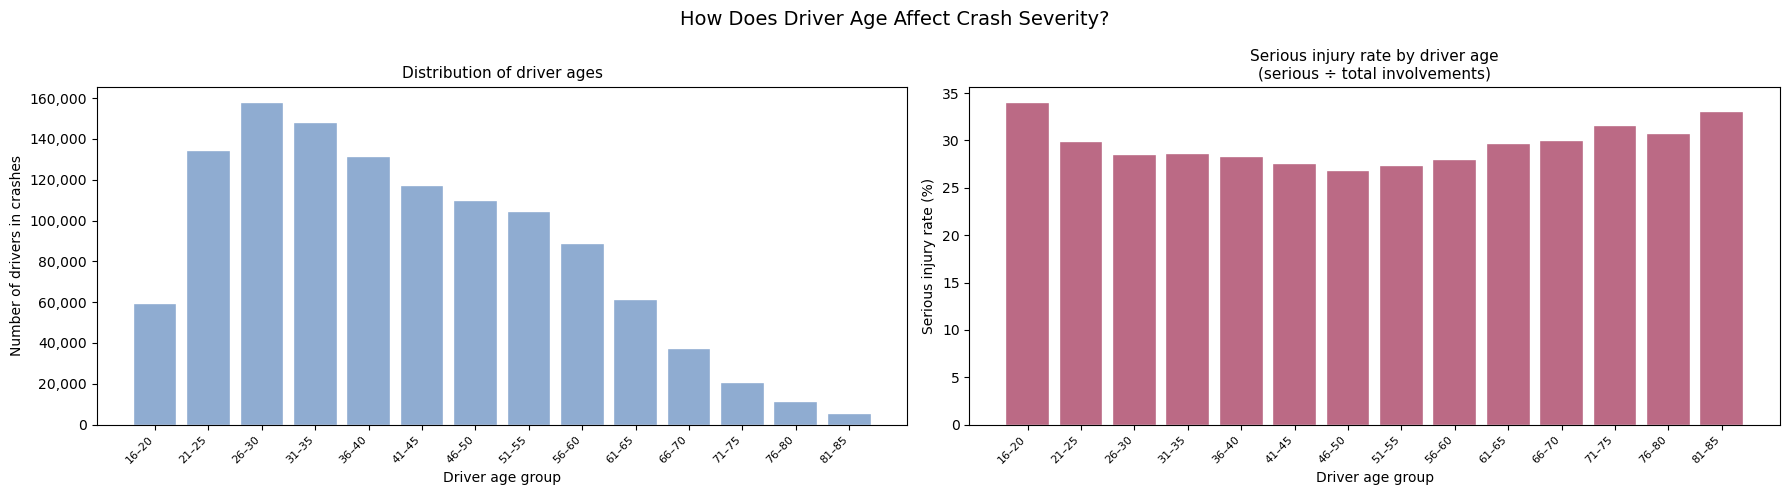

In [43]:
age_df = crashes_with_persons(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    person_cols=['p_PERSON_AGE', 'p_PERSON_TYPE', 'p_POSITION_IN_VEHICLE']
)

age_df = age_df[
    (age_df['p_PERSON_TYPE'] == 'Occupant') &
    (age_df['p_POSITION_IN_VEHICLE'] == 'Driver') &
    (age_df['p_PERSON_AGE'].between(16, 90))
].copy()

age_df['is_serious'] = (
    (age_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (age_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

bin_edges  = list(range(16, 91, 5))
bin_labels = [f'{lo}–{lo+4}' for lo in bin_edges[:-1]]

age_df['age_group'] = pd.cut(age_df['p_PERSON_AGE'],
                              bins=bin_edges, labels=bin_labels,
                              right=True, include_lowest=True)

total   = age_df.groupby('age_group', observed=True).size().reindex(bin_labels, fill_value=0)
serious = age_df[age_df['is_serious']].groupby('age_group', observed=True).size().reindex(bin_labels, fill_value=0)
rate    = (serious / total.replace(0, np.nan) * 100).round(2)

xtick_kw = dict(rotation=45, ha='right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('How Does Driver Age Affect Crash Severity?', fontsize=14)

axes[0].bar(bin_labels, total.values, color='#7B9EC9', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution of driver ages', fontsize=11)
axes[0].set_xlabel('Driver age group')
axes[0].set_ylabel('Number of drivers in crashes')
axes[0].set_xticks(range(len(bin_labels)))
axes[0].set_xticklabels(bin_labels, **xtick_kw)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(bin_labels, rate.values, color='#B05070', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].set_title('Serious injury rate by driver age\n(serious ÷ total involvements)', fontsize=11)
axes[1].set_xlabel('Driver age group')
axes[1].set_ylabel('Serious injury rate (%)')
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, **xtick_kw)

plt.tight_layout()
plt.show()

#### Does the serious injury rate depend on gender?

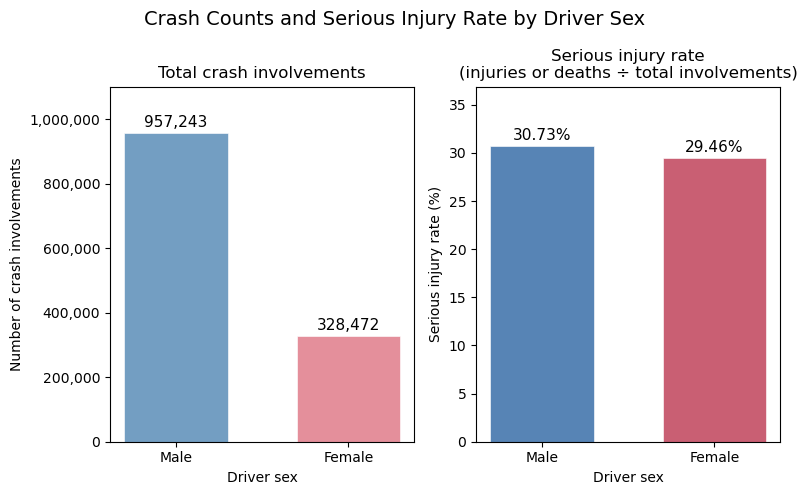

In [44]:
sex_df = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_DRIVER_SEX']
)

sex_df = sex_df[sex_df['v_DRIVER_SEX'].isin(['M', 'F'])].copy()
sex_df['is_serious'] = (
    (sex_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (sex_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

sex_labels  = ['Male', 'Female']
sex_keys    = ['M', 'F']
sex_colors  = ['#5B8DB8', '#E07B8A']

total   = sex_df.groupby('v_DRIVER_SEX').size().reindex(sex_keys)
serious = sex_df[sex_df['is_serious']].groupby('v_DRIVER_SEX').size().reindex(sex_keys)
rate    = (serious / total * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
fig.suptitle('Crash Counts and Serious Injury Rate by Driver Sex', fontsize=14)

# --- total crashes ---
bars = axes[0].bar(sex_labels, total.values, color=sex_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5, width=0.6)
for bar, val in zip(bars, total.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total.max() * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Total crash involvements', fontsize=12)
axes[0].set_xlabel('Driver sex')
axes[0].set_ylabel('Number of crash involvements')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, total.max() * 1.15)

# --- serious injury rate ---
bars = axes[1].bar(sex_labels, rate.values, color=['#3a6fa8', '#c0435a'], alpha=0.85,
                   edgecolor='white', linewidth=0.5, width=0.6)
for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + rate.max() * 0.01,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Serious injury rate\n(injuries or deaths ÷ total involvements)', fontsize=12)
axes[1].set_xlabel('Driver sex')
axes[1].set_ylabel('Serious injury rate (%)')
axes[1].set_ylim(0, rate.max() * 1.2)

plt.tight_layout()
plt.show()

#### Is there any relationship between travelling south/north/east/west and collisions? Is it different depending on gender/age/vehicle occupants?

In [45]:
print("p_PERSON_TYPE values:\n", person_df['p_PERSON_TYPE'].value_counts())
print("\np_POSITION_IN_VEHICLE values (Occupants only):")
print(person_df[person_df['p_PERSON_TYPE'] == 'Occupant']['p_POSITION_IN_VEHICLE'].value_counts())

p_PERSON_TYPE values:
 p_PERSON_TYPE
Occupant           3411869
Pedestrian          115147
Bicyclist            60952
Other Motorized       9661
Name: count, dtype: int64

p_POSITION_IN_VEHICLE values (Occupants only):
p_POSITION_IN_VEHICLE
Driver                                                                                    1198676
Front passenger, if two or more persons, including the driver, are in the front seat       204706
Right rear passenger or motorcycle sidecar passenger                                        81800
Left rear passenger, or rear passenger on a bicycle, motorcycle, snowmobile                 77414
Unknown                                                                                     55297
Any person in the rear of a station wagon, pick-up truck, all passengers on a bus, etc      49773
Middle rear seat, or passenger lying across a seat                                          25309
Middle front seat, or passenger lying across a seat                      

In [46]:
dir_df = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_TRAVEL_DIRECTION', 'v_DRIVER_SEX']
)

print("v_TRAVEL_DIRECTION values:\n", dir_df['v_TRAVEL_DIRECTION'].value_counts())
print("\nv_DRIVER_SEX values:\n",      dir_df['v_DRIVER_SEX'].value_counts())

v_TRAVEL_DIRECTION values:
 v_TRAVEL_DIRECTION
North        414613
South        399617
East         390318
West         388416
Unknown       78066
Northeast     26049
Southeast     25023
Southwest     23618
Northwest     22815
-               449
S               129
N               108
W                96
E                91
U                25
Name: count, dtype: int64

v_DRIVER_SEX values:
 v_DRIVER_SEX
M    957243
F    328472
U      5430
Name: count, dtype: int64


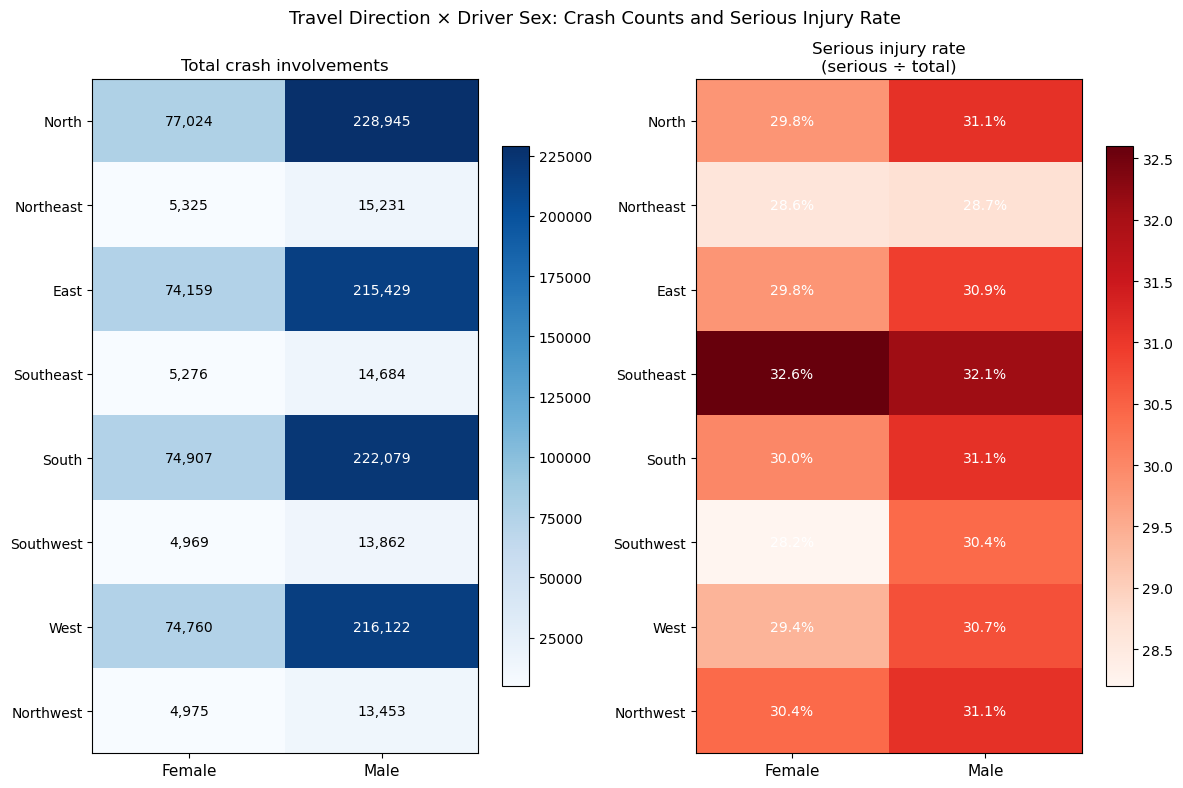

In [47]:
dir_df['is_serious'] = (
    (dir_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (dir_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

# keep known sex and direction only
dir_df = dir_df[
    dir_df['v_DRIVER_SEX'].isin(['M', 'F']) &
    ~dir_df['v_TRAVEL_DIRECTION'].isin(['Unknown'])
].copy()

directions = ['North', 'Northeast', 'East', 'Southeast',
              'South', 'Southwest', 'West', 'Northwest']
sexes = ['F', 'M']

total_pivot   = dir_df.groupby(['v_TRAVEL_DIRECTION', 'v_DRIVER_SEX']).size().unstack('v_DRIVER_SEX')
serious_pivot = dir_df[dir_df['is_serious']].groupby(['v_TRAVEL_DIRECTION', 'v_DRIVER_SEX']).size().unstack('v_DRIVER_SEX')

total_pivot   = total_pivot.reindex(directions)[sexes]
serious_pivot = serious_pivot.reindex(directions)[sexes]
rate_pivot    = (serious_pivot / total_pivot * 100).round(1)

def draw_heatmap(ax, matrix, fmt, title, cmap):
    im = ax.imshow(matrix.values.astype(float), cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(sexes)))
    ax.set_xticklabels(['Female', 'Male'], fontsize=11)
    ax.set_yticks(range(len(directions)))
    ax.set_yticklabels(directions, fontsize=10)
    ax.set_title(title, fontsize=12)
    for i in range(len(directions)):
        for j in range(len(sexes)):
            val = matrix.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, fmt.format(val),
                        ha='center', va='center', fontsize=10,
                        color='white' if val > matrix.values.max() * 0.6 else 'black')

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
fig.suptitle('Travel Direction × Driver Sex: Crash Counts and Serious Injury Rate', fontsize=13)

draw_heatmap(axes[0], total_pivot,   '{:,.0f}', 'Total crash involvements',       'Blues')
draw_heatmap(axes[1], rate_pivot,    '{:.1f}%', 'Serious injury rate\n(serious ÷ total)', 'Reds')

plt.tight_layout()
plt.show()

#### Who gets killed or injured?

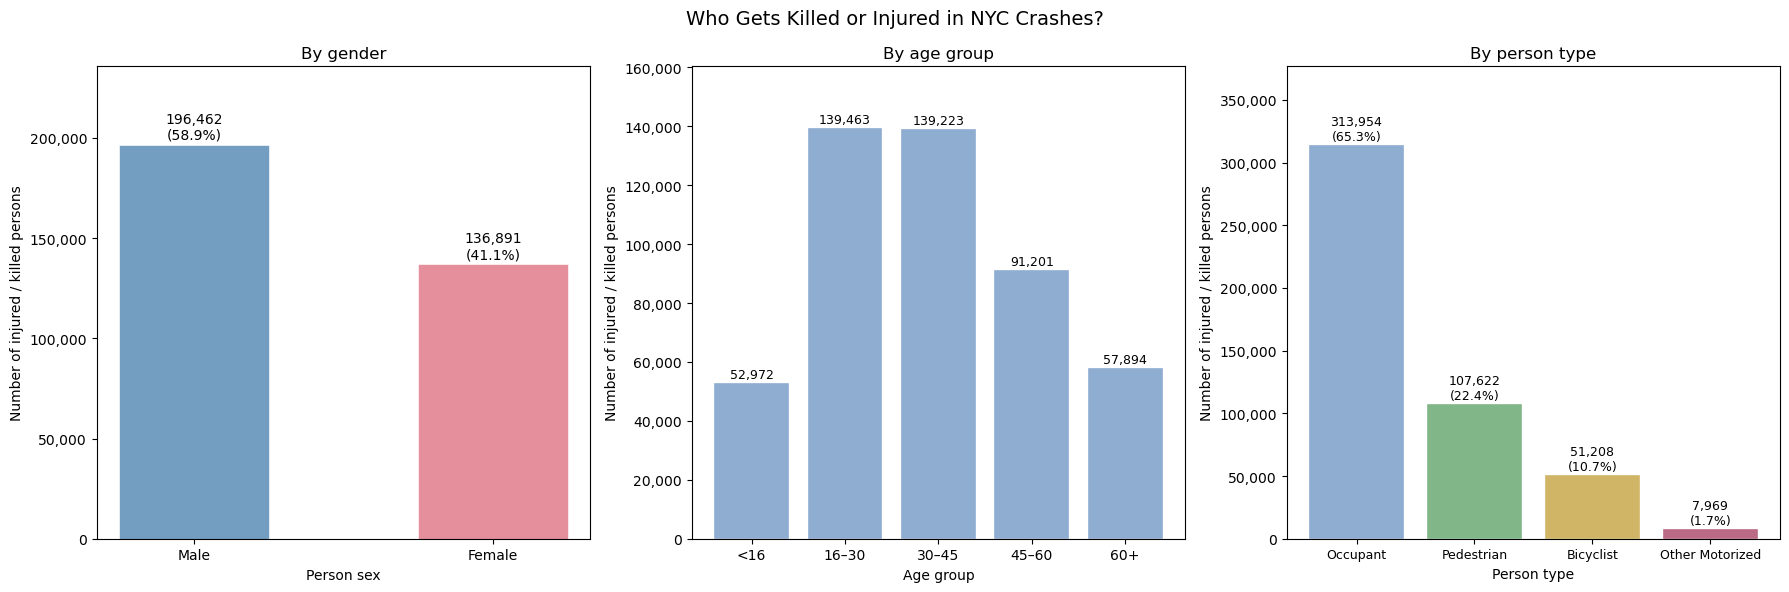

In [48]:
inj = person_df[person_df['p_PERSON_INJURY'].isin(['Injured', 'Killed'])].copy()
inj = inj[inj['p_PERSON_AGE'].between(0, 100)]

fmt_y = plt.FuncFormatter(lambda x, _: f'{int(x):,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Who Gets Killed or Injured in NYC Crashes?', fontsize=14)

# --- gender ---
sex_counts = inj['p_PERSON_SEX'].value_counts().reindex(['M', 'F'], fill_value=0)
sex_labels = ['Male', 'Female']
sex_colors = ['#5B8DB8', '#E07B8A']
total_sex  = sex_counts.sum()

bars = axes[0].bar(sex_labels, sex_counts.values, color=sex_colors,
                   alpha=0.85, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, sex_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total_sex * 0.005,
                 f'{val:,}\n({val / total_sex * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('By gender', fontsize=12)
axes[0].set_xlabel('Person sex')
axes[0].set_ylabel('Number of injured / killed persons')
axes[0].yaxis.set_major_formatter(fmt_y)
axes[0].set_ylim(0, sex_counts.max() * 1.2)

# --- age group ---
age_bins   = [0, 16, 30, 45, 60, 101]
age_labels = ['<16', '16–30', '30–45', '45–60', '60+']
inj['age_group'] = pd.cut(inj['p_PERSON_AGE'], bins=age_bins, labels=age_labels, right=False)
age_counts = inj['age_group'].value_counts().reindex(age_labels, fill_value=0)

axes[1].bar(age_labels, age_counts.values, color='#7B9EC9',
            alpha=0.85, edgecolor='white', linewidth=0.3)
for i, val in enumerate(age_counts.values):
    axes[1].text(i, val + age_counts.max() * 0.005, f'{val:,}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('By age group', fontsize=12)
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Number of injured / killed persons')
axes[1].yaxis.set_major_formatter(fmt_y)
axes[1].set_ylim(0, age_counts.max() * 1.15)

# --- person type ---
type_order  = ['Occupant', 'Pedestrian', 'Bicyclist', 'Other Motorized']
type_colors = ['#7B9EC9', '#6BAA75', '#C9A84C', '#B05070']
type_counts = inj['p_PERSON_TYPE'].value_counts().reindex(type_order, fill_value=0)
total_type  = type_counts.sum()

bars = axes[2].bar(type_order, type_counts.values, color=type_colors,
                   alpha=0.85, edgecolor='white', linewidth=0.3)
for bar, val in zip(bars, type_counts.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total_type * 0.003,
                 f'{val:,}\n({val / total_type * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[2].set_title('By person type', fontsize=12)
axes[2].set_xlabel('Person type')
axes[2].set_ylabel('Number of injured / killed persons')
axes[2].yaxis.set_major_formatter(fmt_y)
axes[2].tick_params(axis='x', labelsize=9)
axes[2].set_ylim(0, type_counts.max() * 1.2)

plt.tight_layout()
plt.show()

#### Is it safer to walk on the left or right side of the road - is there more pedestrian deaths/serious injuries when vehicle is turning right/left?

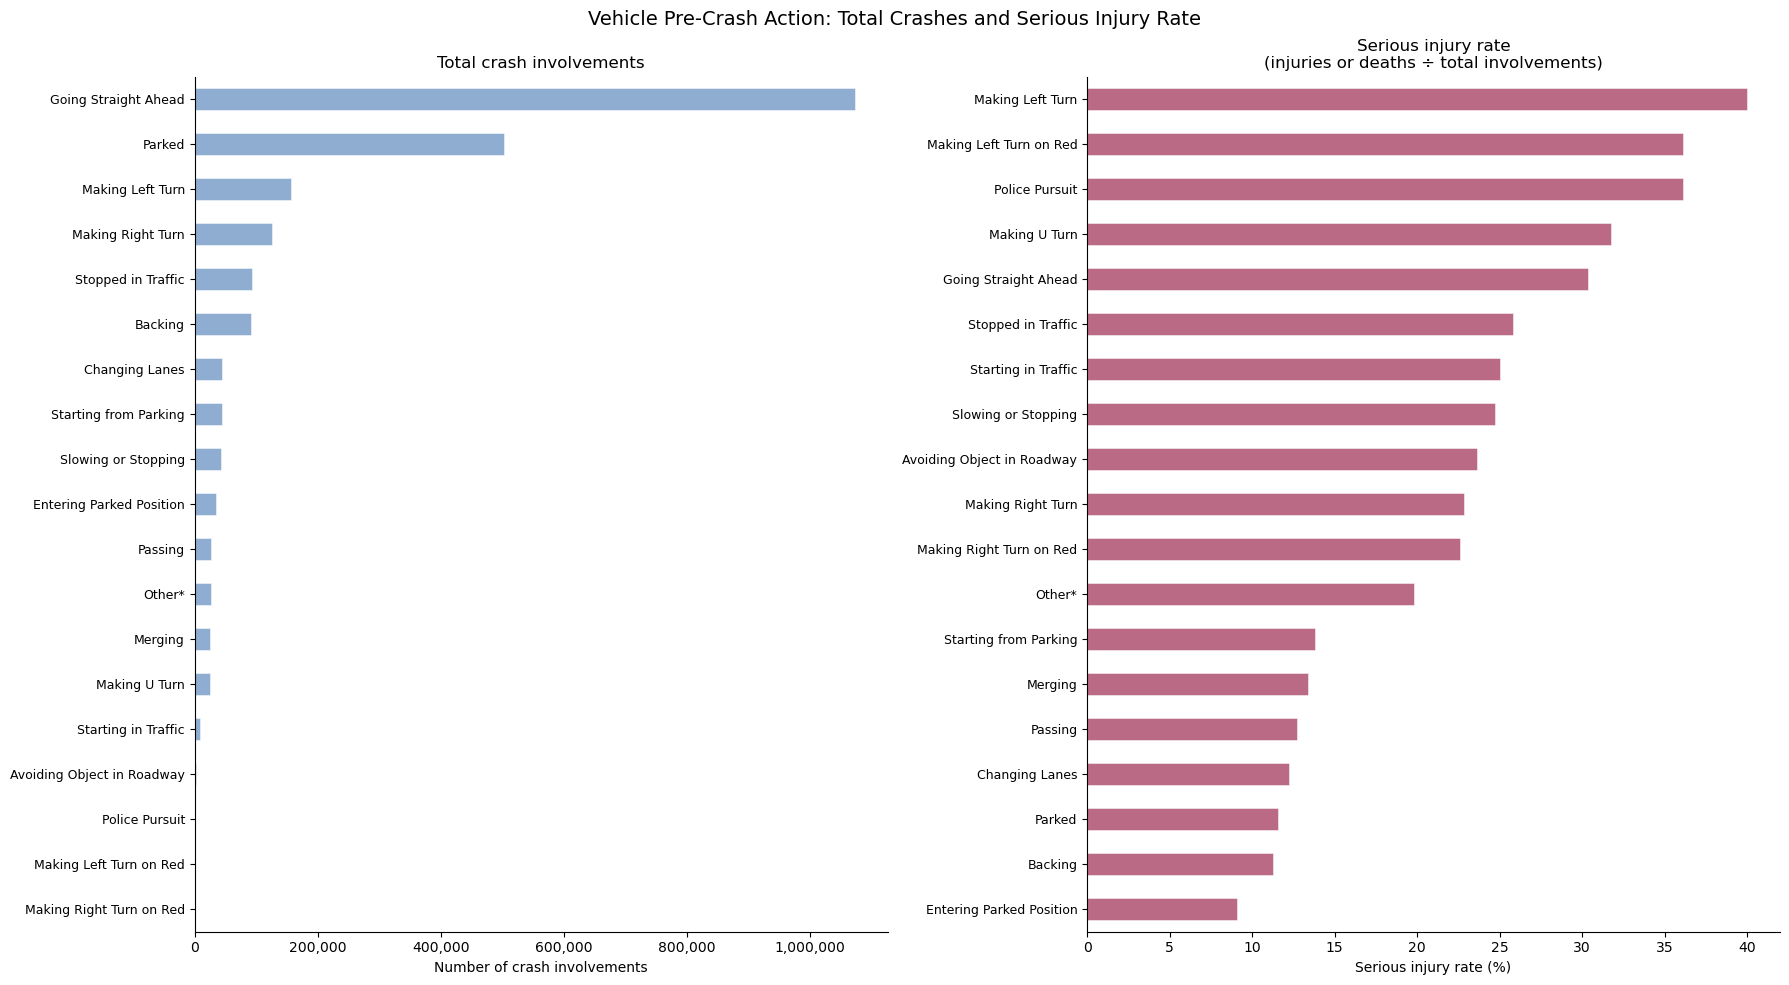

In [49]:
pre_df = crashes_with_vehicles(
    crash_cols=['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED'],
    vehicle_cols=['v_PRE_CRASH']
)

pre_df = pre_df[~pre_df['v_PRE_CRASH'].isin(['Unknown', 'Not Reported'])].dropna(subset=['v_PRE_CRASH']).copy()
pre_df['is_serious'] = (
    (pre_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (pre_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

total   = pre_df.groupby('v_PRE_CRASH').size().sort_values(ascending=False)
serious = pre_df[pre_df['is_serious']].groupby('v_PRE_CRASH').size().reindex(total.index, fill_value=0)
rate    = (serious / total * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Vehicle Pre-Crash Action: Total Crashes and Serious Injury Rate', fontsize=14)

# --- total crashes ---
total.plot(kind='barh', ax=axes[0], color='#7B9EC9', alpha=0.85, edgecolor='white', linewidth=0.4)
axes[0].invert_yaxis()
axes[0].set_title('Total crash involvements', fontsize=12)
axes[0].set_xlabel('Number of crash involvements')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='y', labelsize=9)

# --- serious injury rate — sorted by rate descending ---
rate_sorted = rate.sort_values(ascending=False)
rate_sorted.plot(kind='barh', ax=axes[1], color='#B05070', alpha=0.85, edgecolor='white', linewidth=0.4)
axes[1].invert_yaxis()
axes[1].set_title('Serious injury rate\n(injuries or deaths ÷ total involvements)', fontsize=12)
axes[1].set_xlabel('Serious injury rate (%)')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Are multiple-vehicle accidents more deadly?

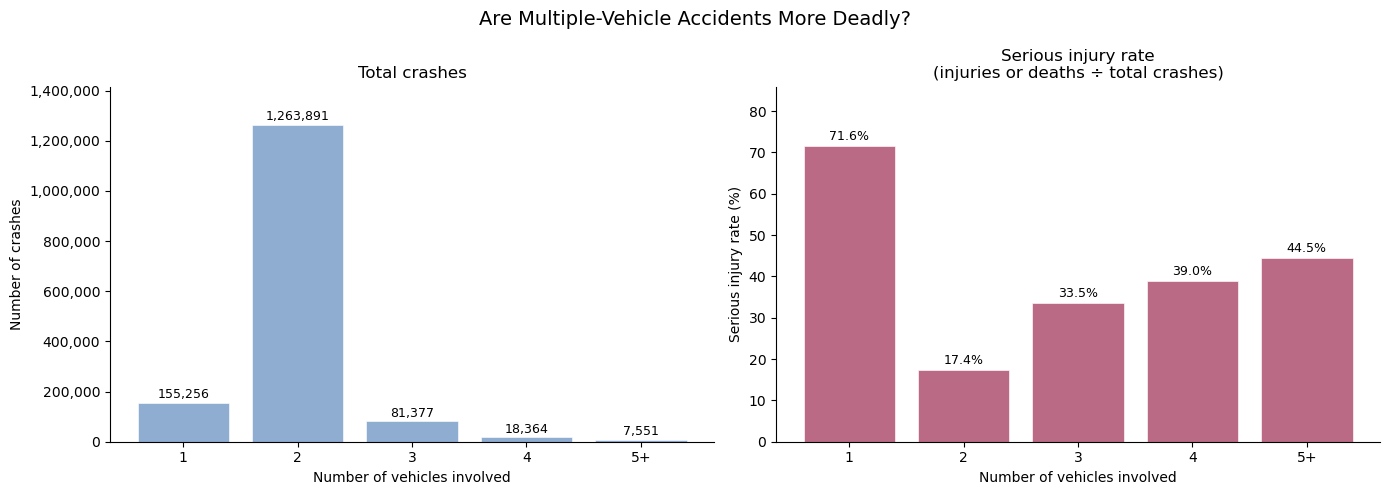

In [50]:
n_veh = vehicle_df.groupby(vehicle_df.index).size().rename('n_vehicles')

mv_df = crash_df[['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED']].join(n_veh)
mv_df = mv_df.dropna(subset=['n_vehicles']).copy()
mv_df['n_vehicles'] = mv_df['n_vehicles'].astype(int)
mv_df['is_serious'] = (
    (mv_df['c_NUMBER OF PERSONS INJURED'] > 0) |
    (mv_df['c_NUMBER OF PERSONS KILLED'] > 0)
)

MAX_VEH = 5
mv_df['veh_group'] = mv_df['n_vehicles'].clip(upper=MAX_VEH)
veh_keys = list(range(1, MAX_VEH + 1))
veh_lbl  = [str(n) for n in range(1, MAX_VEH)] + [f'{MAX_VEH}+']

total   = mv_df.groupby('veh_group').size().reindex(veh_keys, fill_value=0)
serious = mv_df[mv_df['is_serious']].groupby('veh_group').size().reindex(veh_keys, fill_value=0)
rate    = (serious / total.replace(0, np.nan) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Are Multiple-Vehicle Accidents More Deadly?', fontsize=14)

# --- total crashes ---
bars = axes[0].bar(veh_lbl, total.values, color='#7B9EC9', alpha=0.85,
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, total.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total.max() * 0.005,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Total crashes', fontsize=12)
axes[0].set_xlabel('Number of vehicles involved')
axes[0].set_ylabel('Number of crashes')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, total.max() * 1.12)

# --- serious injury rate ---
bars = axes[1].bar(veh_lbl, rate.values, color='#B05070', alpha=0.85,
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, rate.values):
    if pd.notna(val):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + rate.max() * 0.01,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Serious injury rate\n(injuries or deaths ÷ total crashes)', fontsize=12)
axes[1].set_xlabel('Number of vehicles involved')
axes[1].set_ylabel('Serious injury rate (%)')
axes[1].set_ylim(0, rate.max() * 1.2)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

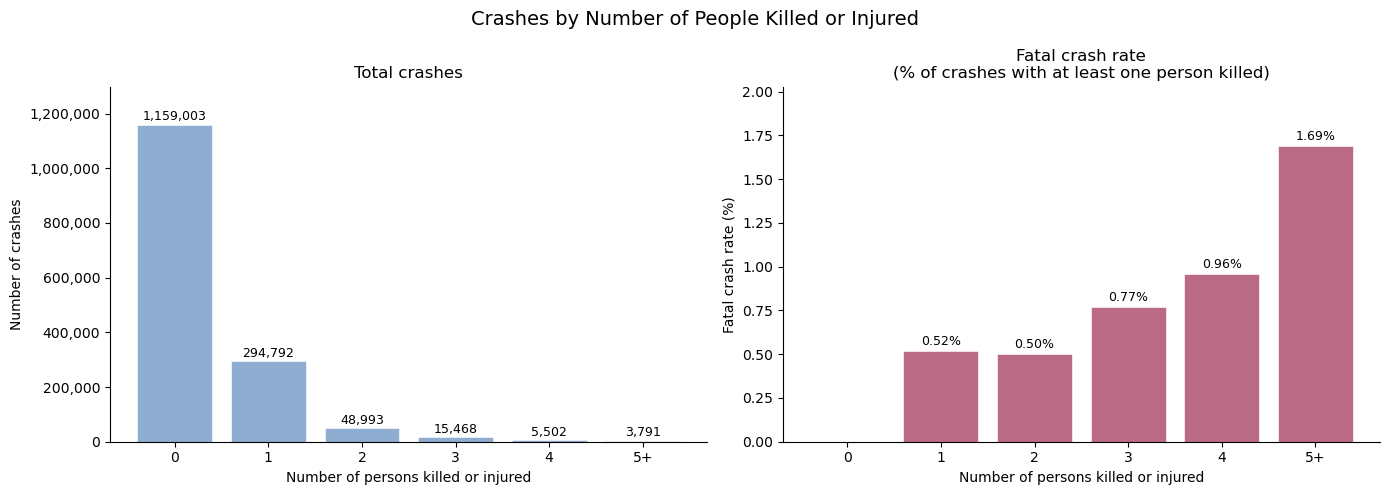

In [51]:
cas_df = crash_df[['c_NUMBER OF PERSONS INJURED', 'c_NUMBER OF PERSONS KILLED']].copy()
cas_df['total_casualties'] = cas_df['c_NUMBER OF PERSONS INJURED'] + cas_df['c_NUMBER OF PERSONS KILLED']
cas_df['has_killed']       = cas_df['c_NUMBER OF PERSONS KILLED'] > 0

MAX_CAS  = 5
cas_df['cas_group'] = cas_df['total_casualties'].clip(upper=MAX_CAS)
cas_keys = list(range(0, MAX_CAS + 1))
cas_lbl  = [str(n) for n in range(0, MAX_CAS)] + [f'{MAX_CAS}+']

total        = cas_df.groupby('cas_group').size().reindex(cas_keys, fill_value=0)
fatality_rate = (cas_df.groupby('cas_group')['has_killed'].mean() * 100
                 ).reindex(cas_keys, fill_value=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crashes by Number of People Killed or Injured', fontsize=14)

# --- total crashes ---
bars = axes[0].bar(cas_lbl, total.values, color='#7B9EC9', alpha=0.85,
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, total.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total.max() * 0.005,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Total crashes', fontsize=12)
axes[0].set_xlabel('Number of persons killed or injured')
axes[0].set_ylabel('Number of crashes')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, total.max() * 1.12)

# --- fatality rate ---
bars = axes[1].bar(cas_lbl, fatality_rate.values, color='#B05070', alpha=0.85,
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, fatality_rate.values):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + fatality_rate.max() * 0.01,
                     f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Fatal crash rate\n(% of crashes with at least one person killed)', fontsize=12)
axes[1].set_xlabel('Number of persons killed or injured')
axes[1].set_ylabel('Fatal crash rate (%)')
axes[1].set_ylim(0, fatality_rate.max() * 1.2)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## If relevant, talk about your machine-learning

# 4. **Genre**: Which genre of data story did you use?

## Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

For **visual structuring** we used a consistent visual platform throughout the website. Same typography mostly, section numbering and layout is maintained. The helps the reader stay oriented as they scroll through the narrative. 

For **highligthing** we use feature distinction by pulling quotes on the website and making them distinct from the from the rest of text to higlight important findings and capture essences of the section.

For **transition guidance** we use familar objects by having a clearly defined structure of text motivating the upcoming visual, text explaining the visual and motivating next visual. This means after reader has completed the first finding they can subconciously anticipate the format of the next finding and the trajectory of the story 

## Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

For **ordering** we used a linear ordering structure. The story follows a fixed sequence of what was promised, what is the current reality, why, where and what can be done. This slowly introduces the reader to the problems and allows them to appreciate the indivudal findings and breakdowns.

For **interactivity** we used hover higlighting and deatils on demand. The reader is allowed to inspect individual points, and slow down some plots for their own investigation. Some plots do also use limited interactivity to keep the reader in context of the story until the end at least. 

For **messaging** we used introductory text at the start of the page. This is used to setup an initial motivation and promise of the story and start asking questions by introdcuing vision zero and whether it has fulfilled its promises. Finally we also use summary to combine findings into a conclusion and what next steps could be in an investigation.

# 5. **Visualizations**

## Explain the visualizations you've chosen

## Why are they right for the story to tell?

# 6. **Discussion**

## What went well?

Working with the data went quite well in regards to working across multiple datasets and merging with the use of collisions ids and time stamps and dates for weather data. Providing perspective to the findings through the use of normlization was also a good idea to bring a new perspective to the data with regards to what was dangerous vs. not.

## What is still missing? What could be improved?, Why?

The normalization of deaths using total collisions is useful but incomplete. Our approach just assumes that more collisions is correlated with more each type passing by a specific spot at a specific time. Better would be to know how many pedestrians, cyclist and motorist cross the different sections each day.

Not necessarily and improvement but an alternate version of the story could have been to entriely focus on the progress of vision zero, track the initiatives over years, and see how this affected outcomes. This would require access to all new traffic light setups, speed cameras etc. when they were setup and where. This was considered, but the access to the data was a challenge and we already had quite an extensive dataset to work with.

This story focuses mostly on deaths compared to collisions in general but there are potentially many nuances and configurations to look into using just the injuries since there is access to the type of injury and what person experienced the injury. This could inform a new story that focuses on not just the design of urban traffic design but the design of the vehicles people use.

# 7. **Contributions**: Who did what?